# Six-dataset motor-imagery preprocessing (v2)
**PhysioNet + Cho2017 + Lee2019 + BNCI2014-001 + Weibo2014 + Dreyer2023**

Config-driven, ablation-instrumented, audit-gated. Every dataset-specific fact lives in one `DatasetConfig`; every design choice that could have gone another way is a hyperparameter in `GlobalConfig` and has an ablation block.

## What changed in this revision

**1. Cue-onset alignment — the correctness fix.** MOABB stores each dataset's usable task window in an `interval` attribute: `BNCI2014_001` is `[2, 6]` because the trial opens with a 2 s fixation cross and the arrow cue only appears at t = 2 s; `Weibo2014` is `[3, 7]`. In MOABB 1.0.0 `SetRawAnnotations` wrote annotations at the *trial* onset rather than at `onset + interval[0]` (fixed by MOABB PR #607, shipped in 1.1). MOABB's own paradigms were unaffected because they add `interval[0]` themselves — but this notebook loads raws and epochs **externally from the annotations**, which is exactly the case the PR author flagged. The previous version assumed offset 0 for all six datasets; on MOABB 1.0.0 that made the BNCI2014-001 "imagery window" the fixation cross. Now resolved at runtime and printed.

**2. Channel harmonization is a hyperparameter with three settings.** `reference_masked` (new default) takes the PhysioNet ∩ Cho2017 anchor intersection (~62 channels, computed live) and expresses every other dataset in it — real channels kept, never-recorded channels zero-filled and carried in a boolean mask. `union` and `intersection` remain for the ablation. Section 15 compares all three.

**3. Hilbert edge effects fixed with real-data margins.** Reflection padding, the intuitive remedy, measures *worse* than doing nothing on narrowband data. See Section 18.

**4. Evaluation leakage.** Stratified group CV, empirical chance, per-dataset breakdowns, EA declared transductive vs inductive, and a dataset-identity shortcut probe.

**5. The channel-set bug.** `build_cohort` silently ignored the `common_channels` it was given and recomputed the intersection, so every previous ablation table described a pipeline the notebook was not running.

Full changelog in `preprocessing_pkg/README.md`.

**Requires:** `mne`, `moabb`, `mne-icalabel`, `autoreject`, `pyriemann`, `umap-learn`, `torch`, plus local PhysioNet EDF files.

In [1]:
!pip install -q mne moabb pyriemann autoreject umap-learn mne-icalabel python-picard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 980.1/980.1 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.6/153.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.2/120.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.8/189.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 2.0 MB/s eta 0:00:00


## Section 0 — Environment and paths

In [2]:
import os
import sys
import shutil
from pathlib import Path

# 1. Locate the source package by a known unique file, so Kaggle's
#    folder-naming quirks cannot break the lookup.
candidates = list(Path('/kaggle/input').rglob('ablation_suite.py'))
assert candidates, "No preprocessing package found under /kaggle/input"
src_dir = candidates[0].parent
print("source package:", src_dir)

target_link = Path('/kaggle/working/preprocessing_pkg')

# 2. Clear whatever is at the target path -- symlink OR real directory OR
#    leftover file from an earlier session.
if target_link.is_symlink():
    target_link.unlink()
elif target_link.is_dir():
    shutil.rmtree(target_link)
elif target_link.exists():
    target_link.unlink()

# 3. Recreate the symlink.
os.symlink(src_dir, target_link)
print(f"Linked: {target_link} -> {src_dir}")

# 4. Make sure the working directory is first on sys.path.
if '/kaggle/working' not in sys.path:
    sys.path.insert(0, '/kaggle/working')

# 5. Drop any cached imports from earlier runs in this kernel.
for name in [m for m in list(sys.modules) if m == "preprocessing_pkg"
             or m.startswith("preprocessing_pkg.")]:
    del sys.modules[name]

# 6. Import and verify the extra modules are reachable.
import preprocessing_pkg as pkg
from preprocessing_pkg.config import GlobalConfig, DatasetRegistry

print("Successfully imported preprocessing_pkg!")
print("pkg.__file__             :", pkg.__file__)
print("pkg.__version__          :", getattr(pkg, "__version__", None))
print("has configure_output_root:", hasattr(pkg, "configure_output_root"))
print("has qc_reporting         :", hasattr(pkg, "qc_reporting"))
print("has extra_ablations      :", hasattr(pkg, "extra_ablations"))

source package: /kaggle/input/datasets/amirrzh/preprocessing
Linked: /kaggle/working/preprocessing_pkg -> /kaggle/input/datasets/amirrzh/preprocessing
Successfully imported preprocessing_pkg!
pkg.__file__             : /kaggle/working/preprocessing_pkg/__init__.py
pkg.__version__          : 2.2.0
has configure_output_root: True
has qc_reporting         : True
has extra_ablations      : True


In [3]:
import os
import sys
import shutil
import stat
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MNE_DATA_DIR = Path('/tmp/mne_data')
MNE_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Invert the logic: Symlink ONLY large signal data to save RAM/Disk space.
# Everything else (metadata, TSV, JSON, READMEs) gets copied and unlocked.
SIGNAL_EXTENSIONS = {'.edf', '.mat', '.fif', '.set', '.fdt', '.vhdr', '.vmrk', '.eeg', '.pdf', '.bdf', '.gdf'}

print("Unifying mne_data from all 8 Kaggle input partitions...")

for mne_source in Path('/kaggle/input').rglob('mne_data'):
    if not mne_source.is_dir():
        continue
    for root, dirs, files in os.walk(mne_source):
        rel_path = Path(root).relative_to(mne_source)
        dest_dir = MNE_DATA_DIR / rel_path
        dest_dir.mkdir(parents=True, exist_ok=True)
        
        for file in files:
            src_file = Path(root) / file
            dest_file = dest_dir / file
            
            # Avoid re-linking if file already mapped from an earlier partition
            if not (dest_file.exists() or dest_file.is_symlink()):
                if src_file.suffix.lower() in SIGNAL_EXTENSIONS:
                    try:
                        dest_file.symlink_to(src_file)
                    except FileExistsError:
                        pass
                else:
                    # Use copyfile (does not copy read-only metadata like copy2)
                    shutil.copyfile(src_file, dest_file)
                    # Force write permissions (fixes Kaggle's read-only locks)
                    os.chmod(dest_file, dest_file.stat().st_mode | stat.S_IWRITE)

# Unify any pooch/MOABB download caches if present in inputs
root_cache = Path('/root/.cache')
root_cache.mkdir(parents=True, exist_ok=True)
for cache_source in Path('/kaggle/input').rglob('.cache'):
    if cache_source.is_dir():
        for root, dirs, files in os.walk(cache_source):
            rel_cache = Path(root).relative_to(cache_source)
            target_cache_dir = root_cache / rel_cache
            target_cache_dir.mkdir(parents=True, exist_ok=True)
            for f in files:
                src_f = Path(root) / f
                dest_f = target_cache_dir / f
                if not (dest_f.exists() or dest_f.is_symlink()):
                    if src_f.suffix.lower() in SIGNAL_EXTENSIONS:
                        try:
                            dest_f.symlink_to(src_f)
                        except FileExistsError:
                            pass
                    else:
                        shutil.copyfile(src_f, dest_f)
                        os.chmod(dest_f, dest_f.stat().st_mode | stat.S_IWRITE)

print(f"Unified MNE_DATA ready at: {MNE_DATA_DIR}")

# -------------------------------------------------------------
# CONFIGURE PATHS FOR MNE, MOABB, AND PHYSIONET
# -------------------------------------------------------------
MNE_DATA_DIR_STR = str(MNE_DATA_DIR)
PHYSIONET_DIR = os.path.join(MNE_DATA_DIR_STR, 'MNE-eegbci-data', 'files', 'eegmmidb', '1.0.0')

import mne, moabb
mne.set_config('MNE_DATA', MNE_DATA_DIR_STR)
mne.set_config('MNE_DATASETS_EEGBCI_PATH', MNE_DATA_DIR_STR)
moabb.set_download_dir(MNE_DATA_DIR_STR)
os.environ['PHYSIONET_ROOT'] = PHYSIONET_DIR

# Import package modules
import preprocessing_pkg as pkg
from preprocessing_pkg.config import (
    GlobalConfig, DatasetRegistry,
    make_physionet_config, make_cho2017_config, make_lee2019_config,
    make_bnci2014001_config, make_weibo2014_config, make_dreyer2023_config,
)
from preprocessing_pkg import io_loaders, visualization as viz, ablation_suite as abl
from preprocessing_pkg import cohort_analysis as ca, audits
from preprocessing_pkg.channels import (
    standardize_channel_name, build_channel_table, filter_eeg_only,
    resolve_target_channels, build_mapping_table, build_channel_masks,
    summarize_channel_synthesis, verify_common_channels_montage,
    analyze_dataset_harmonization,
)
from preprocessing_pkg.pipeline_builder import (
    build_pipeline_from_config, build_cohort, resolve_car_scope,
)
from preprocessing_pkg.metadata import build_subject_metadata_scaffold
from preprocessing_pkg.baselines import build_all_baselines, FBCSP
from preprocessing_pkg.augmentation import EEGAugmentationTransform

print("preprocessing_pkg", pkg.__version__, "| mne", mne.__version__, "| moabb", moabb.__version__)

Unifying mne_data from all 8 Kaggle input partitions...
Unified MNE_DATA ready at: /tmp/mne_data
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
preprocessing_pkg 2.2.0 | mne 1.12.1 | moabb 1.7.2


In [4]:
import os
import sys
from pathlib import Path

# 1. Locate the true package directory by finding a known unique file inside it.
# This bypasses any hyphen/underscore naming quirks Kaggle applies to the root folder.
pkg_files = list(Path('/kaggle/input').rglob('ablation_suite.py'))

if pkg_files:
    actual_pkg_dir = pkg_files[0].parent
    symlink_path = Path('/kaggle/working/preprocessing_pkg')
    
    # 2. Create a perfectly named symlink in the writable working directory
    if not symlink_path.exists():
        symlink_path.symlink_to(actual_pkg_dir)
        
    # 3. Add the working directory to sys.path so Python finds 'preprocessing_pkg'
    if '/kaggle/working' not in sys.path:
        sys.path.insert(0, '/kaggle/working')
        
    print(f"Package successfully linked: {actual_pkg_dir} -> {symlink_path}")
else:
    raise FileNotFoundError("Could not locate the package files in /kaggle/input.")

# 4. Now the import will work natively
import preprocessing_pkg as pkg
from preprocessing_pkg.config import GlobalConfig, DatasetRegistry

print("preprocessing_pkg imported successfully! Version:", pkg.__version__)

Package successfully linked: /kaggle/input/datasets/amirrzh/preprocessing -> /kaggle/working/preprocessing_pkg
preprocessing_pkg imported successfully! Version: 2.2.0


In [5]:
# Check S001 in unified tree
edf = list(Path(PHYSIONET_DIR).rglob('S001R01.edf'))
assert edf, f"Could not find S001R01.edf in {PHYSIONET_DIR}. Ensure PhysioNet is present in the Kaggle inputs."

# Do NOT call .resolve() here: preserve the unified /tmp path
physionet_root = Path(PHYSIONET_DIR).absolute()
os.environ['PHYSIONET_ROOT'] = str(physionet_root)

print("PhysioNet root:", physionet_root)
print("Resolved test file:", io_loaders.resolve_physionet_edf_path(1, 1, str(physionet_root)))

PhysioNet root: /tmp/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0
Resolved test file: /tmp/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R01.edf


In [6]:
# Every table, figure, JSON payload and log line lands under one root, so a
# Kaggle / Colab disconnect does not take the results with it. /kaggle/working
# is writable and survives until the session ends; copy it to Drive afterwards
# if you want it to survive a kernel reset.
import os
OUTPUT_ROOT = "/kaggle/working/output"
os.makedirs(OUTPUT_ROOT, exist_ok=True)
pkg.configure_output_root(OUTPUT_ROOT)

# Route the audit suite's own file-handler logger into the same tree as well.
artifact_log = pkg.get_artifact_logger("notebook_artifacts")
artifact_log.info(f"Session start. Output root = {OUTPUT_ROOT}")

Session start. Output root = /kaggle/working/output


[output] artifacts will be written under /kaggle/working/output


## Section 1 — Global hyperparameters

Everything that could reasonably have been decided another way is here, not scattered through the notebook.

| hyperparameter | value | what it controls |
|---|---|---|
| `HARMONIZATION_MODE` | `reference_masked` | how datasets with different montages are put in a shared space (Section 3, ablated in Section 15) |
| `ANCHOR_DATASETS` | `(physionet, cho2017)` | which datasets' shared electrodes define that space |
| `CAR_SCOPE` | `shared_support` | which channels the average reference is computed over |
| `ENVELOPE_MARGIN_SEC` | `1.0` | real signal epoched beyond the display window for edge-safe Hilbert |
| `EA_SCOPE` | `subject` | Euclidean Alignment reference scope (both reported in Section 14) |
| `FIR_TRANS_BANDWIDTH` | `2.0` | pinned, because it determines the filter length the leakage audit reasons about |
| `COHORT_N_JOBS` | `4` | worker processes `build_cohort` uses per (dataset, subject) task |

**Performance note (applies from Section 10 on).** `build_cohort` -- the single function every ablation section below funnels through -- now runs one (dataset, subject) pair per `joblib` worker process instead of a plain Python loop, so Sections 10, 12, 13, 14, 15 and 16 are parallelized across subjects with no change at their call sites. Within each subject, every ablation component that used to be fit separately per run (CAR, the Surface Laplacian spline, ICA, bad-channel detection) is now fit **once per subject on the concatenated recording** instead of once per run -- for a 12-run dataset like BNCI2014-001 that turns 12 ICA fits into 1. Section 12's ICA broadband copy is additionally cached to disk (`pkg.configure_cache`, set up below) so a Colab disconnect doesn't cost you subjects you'd already finished. None of this changes what gets computed, only how many times.


In [7]:
import os
import psutil
from dataclasses import replace

# Dynamic worker configuration based on hardware profile
avail_ram_gb = psutil.virtual_memory().total / (1024**3)
optimal_jobs = 2 if avail_ram_gb < 16 else min(4, os.cpu_count() or 2)

# Initialize config and safely update the frozen attribute
base_glob = GlobalConfig()
glob = replace(base_glob, COHORT_N_JOBS=optimal_jobs)

for f in ("TARGET_SFREQ", "EXPECTED_TIME_SAMPLES", "BANDPASS", "FIR_TRANS_BANDWIDTH",
          "HARMONIZATION_MODE", "ANCHOR_DATASETS", "CAR_SCOPE",
          "ENVELOPE_MARGIN_SEC", "EA_SCOPE", "CV_FOLDS", "COHORT_N_JOBS"):
    print(f"{f:26s} = {getattr(glob, f)}")

print(f"{'PRIMARY_EPOCH_WINDOW':26s} = {glob.PRIMARY_EPOCH_WINDOW}  (CUE-relative)")
print(f"{'BASELINE_ABLATION_WINDOW':26s} = {glob.BASELINE_ABLATION_EPOCH_WINDOW}")

# Configure scratch disk cache in /tmp to avoid Kaggle's 20GB output limit
CACHE_DIR = "/tmp/pipeline_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
pkg.configure_cache(CACHE_DIR)
pkg.suppress_warnings()

TARGET_SFREQ               = 128.0
EXPECTED_TIME_SAMPLES      = 256
BANDPASS                   = (8.0, 30.0)
FIR_TRANS_BANDWIDTH        = 2.0
HARMONIZATION_MODE         = reference_masked
ANCHOR_DATASETS            = ('physionet', 'cho2017')
CAR_SCOPE                  = shared_support
ENVELOPE_MARGIN_SEC        = 1.0
EA_SCOPE                   = subject
CV_FOLDS                   = 5
COHORT_N_JOBS              = 4
PRIMARY_EPOCH_WINDOW       = {'tmin': 1.0, 'tmax': 2.9921875}  (CUE-relative)
BASELINE_ABLATION_WINDOW   = {'tmin': -0.5, 'tmax': 2.0}
[cache] Disk cache enabled at: /tmp/pipeline_cache
[warnings] Suppressed for this session (driver process only -- parallel workers already suppress their own independently).


## Section 2 — Dataset registry

All six are natively binary or restricted to `left_hand`/`right_hand` via `event_id`. Each config records its own sampling rate, event vocabulary, valid runs, post-cue trial length, clean pre-cue budget, online-feedback onset, and MOABB `interval` — with a reason for every exclusion.
**Dreyer2023 fix applied here:** the loader below is bound to `acquisition_only=True`, keeping only the sham-feedback runs (R1/R2) instead of all 6 -- see the inline comment in the cell below for why.

In [8]:
from functools import partial
from preprocessing_pkg.io_loaders import (
    load_physionet_subject_runs, get_physionet_channel_info,
    load_cho2017_subject_runs, get_cho2017_channel_info,
    load_lee2019_subject_runs, get_lee2019_channel_info,
    load_bnci2014001_subject_runs, get_bnci2014001_channel_info,
    load_weibo2014_subject_runs, get_weibo2014_channel_info,
    load_dreyer2023_subject_runs, get_dreyer2023_channel_info, make_dreyer2023_loader,
)

# --- RAM FIX (replaces the old cell-14 on-disk source patch) --------------
# `load_lee2019_subject_runs` defaults to `sessions=(1, 2)` -- both offline
# OpenBMI sessions, 62 ch @ 1000 Hz each, ~100 trials/session. At that
# native rate a single session's continuous recording is ~0.6-0.7 GB as a
# float64 MNE Raw; MOABB's own `_get_single_subject_data` loads every
# requested session's .mat file before anything is filtered or resampled,
# so `sessions=(1, 2)` means BOTH are resident in RAM at once, ~1.3+ GB,
# before `preprocess_raw` ever gets a chance to bring it down to 128 Hz.
# No other dataset here runs anywhere near that native rate (next-highest
# is Cho2017/Dreyer2023 at 512 Hz, already ~2x cheaper per second).
#
# Binding the loader to ONE session with `functools.partial` is a plain
# Python closure over the *unmodified* package function -- it changes
# nothing inside preprocessing_pkg, is visible and reversible from the
# notebook, and (unlike the old cell 14) does not depend on matching an
# exact source line in a file on disk, so it can't silently become a
# no-op if the package changes. Trade-off, stated explicitly: this halves
# the trials contributed per Lee2019 subject (one offline session instead
# of two) -- the same kind of scope reduction the pilot subject counts in
# Section 9 already make, and the right lever for a RAM-constrained run.
# Flip back to `sessions=(1, 2)` once you have headroom (a high-RAM
# runtime, or COHORT_N_JOBS=1 with nothing else resident) and want the
# full two-session cohort for the numbers you'll actually report.
LEE2019_SESSIONS = (1,)
load_lee2019_subject_runs_bounded = partial(load_lee2019_subject_runs,
                                             sessions=LEE2019_SESSIONS)
print(f"[lee2019 RAM fix] loader bound to session(s) {LEE2019_SESSIONS} "
      f"(package default is (1, 2)) -- halves Lee2019's native-rate memory "
      f"footprint per subject.")

# Cache channel-info probes: each one downloads/opens a recording, and the
# registry queries them repeatedly.
_channel_info_fns = {
    "physionet":   get_physionet_channel_info,
    "cho2017":     get_cho2017_channel_info,
    "lee2019":     get_lee2019_channel_info,
    "bnci2014001": get_bnci2014001_channel_info,
    "weibo2014":   get_weibo2014_channel_info,
    "dreyer2023":  get_dreyer2023_channel_info,
}
_cache = {}
def cached_names(name):
    def _fn():
        if name not in _cache:
            n, t, s = _channel_info_fns[name]()
            # Keep only scalp EEG at source -- this replaces the two cells of
            # post-hoc NON_EEG filtering the previous notebook needed.
            from preprocessing_pkg.channels import scalp_eeg_names
            _cache[name] = scalp_eeg_names(n, t)
            print(f"[{name}] {len(_cache[name])} scalp EEG channels @ {s:.0f} Hz")
        return _cache[name]
    return _fn

registry = DatasetRegistry(
    make_physionet_config(load_physionet_subject_runs, cached_names("physionet")),
    make_cho2017_config(load_cho2017_subject_runs, cached_names("cho2017")),
    make_lee2019_config(load_lee2019_subject_runs_bounded, cached_names("lee2019")),
    make_bnci2014001_config(load_bnci2014001_subject_runs, cached_names("bnci2014001")),
    make_weibo2014_config(load_weibo2014_subject_runs, cached_names("weibo2014")),
    # acquisition_only=True keeps runs R1/R2 only (sham feedback, not driven
    # by an online classifier). The default (all 6 runs) leaves the primary
    # window (1.0-2.99s post-cue) sitting inside R3-R6's real-time feedback
    # bar, which starts at cue+1.25s and is driven by the running LDA -- so
    # its visually evoked response is correlated with the trial's TRUE label
    # only insofar as the online classifier is accurate, but is not a clean
    # measurement of imagery either way. Restricting to R1/R2 removes that
    # confound at the cost of roughly 2/6 of this dataset's trials per subject.
    make_dreyer2023_config(make_dreyer2023_loader(acquisition_only=True),
                           cached_names("dreyer2023")),
)
registry.enable_only("physionet", "cho2017", "lee2019",
                     "bnci2014001", "weibo2014", "dreyer2023")
print("Configured:", [c.name for c in registry.enabled()])


[lee2019 RAM fix] loader bound to session(s) (1,) (package default is (1, 2)) -- halves Lee2019's native-rate memory footprint per subject.
Configured: ['physionet', 'cho2017', 'lee2019', 'bnci2014001', 'weibo2014', 'dreyer2023']


## Section 2b — Cue-onset resolution (run this before anything epochs)

This is the cell that decides whether the "imagery window" is imagery.

`resolve_cue_offset` reads the installed MOABB version and each dataset's declared `interval`. On MOABB ≥ 1.1 annotations already sit at `onset + interval[0]`, so every offset is 0. On 1.0.0 BNCI2014-001 needs +2.0 s and Weibo2014 needs +3.0 s, or their epochs land on the fixation cross.

`resolve_cue_offset(..., override=...)` pins a value by hand if you have verified alignment empirically.

In [9]:
print("MOABB places annotations at onset+interval[0]:",
      io_loaders.moabb_annotations_include_interval_offset())
print()
offsets = io_loaders.apply_cue_offsets(registry)   # writes cfg.cue_offset_sec
print()
_ = registry.cue_alignment_table()

MOABB places annotations at onset+interval[0]: True

[cue offset] physionet: +0.00s (annotations built directly at cue onset)
[cue offset] cho2017: +0.00s (MOABB interval starts at 0)
[cue offset] lee2019: +0.00s (annotations built directly at cue onset)
[cue offset] bnci2014001: +0.00s -- MOABB 1.7.2 >= 1.1 already places annotations at onset+interval[0] (2.0s).
[cue offset] weibo2014: +0.00s -- MOABB 1.7.2 >= 1.1 already places annotations at onset+interval[0] (3.0s).
[cue offset] dreyer2023: +0.00s (MOABB interval starts at 0)


================= CUE-ONSET ALIGNMENT =================
    dataset moabb_interval  cue_offset_sec  post-cue trial length (s)  clean pre-cue (s)  feedback onset (s post-cue)
  physionet     (0.0, 3.0)             0.0                        4.0                2.0                          NaN
    cho2017     (0.0, 3.0)             0.0                        3.0                2.0                          NaN
    lee2019     (0.0, 4.0)             0.0          

In [10]:
# Empirical cross-check on one recording per dataset. MOABB sets the annotation
# DURATION to interval[1]-interval[0] in every version, so a duration matching the
# declared post-cue trial length is consistent; the median inter-onset interval
# should match the documented trial period. Neither proves onset placement on its
# own -- that is what the version rule above is for -- but a mismatch here means
# something is wrong and should be investigated before trusting any result.
rows = []
for cfg in registry.enabled():
    try:
        raws = cfg.loader_fn(1)
        info = io_loaders.describe_annotation_timing(raws[0], cfg.event_id, cfg.name)
        info["declared_trial_length"] = cfg.trial_length_sec
        info["cue_offset_applied"] = cfg.cue_offset_sec
        rows.append(info)
    except Exception as exc:
        print(f"[{cfg.name}] timing probe skipped: {exc}")
pd.DataFrame(rows)[["dataset", "n_matching_annotations", "median_duration_sec",
                    "median_inter_onset_sec", "declared_trial_length",
                    "cue_offset_applied"]]

Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Starting caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012


Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_rec

Finished caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012 to disk.
Trial data de-meaned and concatenated with a buffer to create cont data
0it [00:00, ?it/s]Downloading data from 'https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67bec1ce2052c3c2a12e92c9' to file '/tmp/mne_data/MNE-dreyer2023-data/code.zip'.


  0%|                                              | 0.00/89.0k [00:00<?, ?B/s]

SHA256 hash of downloaded file: 691dc5bf07021e2030a0a58c3242802dfb5306228c90081bca097b8e6290b972
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
2it [00:01,  1.11it/s]Downloading data from 'https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67bec1d03ca1517c49bd5867' to file '/tmp/mne_data/MNE-dreyer2023-data/derivatives.zip'.


...

SHA256 hash of downloaded file: a5bc6906cced90e49bf288ccb0fd78c2f6359d0631a4f6178a9f0f2723d39bc2
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
8it [00:05,  1.62it/s]Downloading data from 'https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67c9aaa76e4ba1d657fd7556' to file '/tmp/mne_data/MNE-dreyer2023-data/sub-01.zip'.


  0%|                                              | 0.00/72.6M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 7c9b290700381e9f06025eb3248d8118eae57d6ae36c393f4d265596c63a82c1
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
9it [00:09,  1.08s/it]


Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...


,dataset,n_matching_annotations,median_duration_sec,median_inter_onset_sec,declared_trial_length,cue_offset_applied
0,physionet,15,4.1,8.300,4.0,0.0
1,cho2017,200,3.0,7.000,3.0,0.0
2,lee2019,100,4.0,10.967,4.0,0.0
3,bnci2014001,24,4.0,15.616,4.0,0.0
4,weibo2014,160,4.0,17.000,4.0,0.0
5,dreyer2023,40,5.0,11.000,5.0,0.0


## Section 3 — Channel harmonization

`HARMONIZATION_MODE` is applied here and nowhere else. The audit, the mapping table, the montage check and the per-dataset channel masks all derive from one call, so `common_channels` cannot drift out of sync with what the pipeline processes — which is what used to happen when one cell ran the audit in `union` mode and another in `intersection`.

**Why `reference_masked` is the default.** Dreyer2023 records 27 electrodes, all between Fz and Pz: no frontopolar, no temporal, no occipital coverage at all. Union mode asks spherical-spline interpolation to produce Fp1, O1 and T7 for it — extrapolation from >10 cm away. Worse, interpolated rows are exact linear combinations of the recorded ones, so the tensor's numerical rank stays at 27 however many rows it gains, and inter-channel correlation is inflated for purely algebraic reasons (Kang, Lano & Sponheim 2015). The reference-masked space keeps every electrode the anchor datasets genuinely recorded and states missing-ness rather than guessing it.

In [11]:
# --- SUPERSEDED (RAM fix) ---------------------------------------------
# This cell used to patch /content/preprocessing_pkg/io_loaders.py on disk
# to change Lee2019's default session. Two problems with that: (1) it
# silently stops working the moment the package's default changes, with
# no error -- it did in this revision, since the default is now
# `sessions=(1, 2)`, not `sessions=(0,)`; (2) rewriting a package file
# mid-session is fragile and hard to reason about (every subsequent
# `import` in every joblib worker process re-reads whatever is on disk
# at THAT moment).
#
# The session restriction now happens once, safely, in cell 9 via
# `functools.partial(load_lee2019_subject_runs, sessions=(1,))` -- a
# plain closure over the unmodified package function. No file on disk is
# touched. Nothing to run here.
print("[lee2019] session binding now handled in cell 9 -- no file patch applied.")


[lee2019] session binding now handled in cell 9 -- no file patch applied.


In [12]:
import importlib
import sys

# Force reload the package and its submodules so the new patched code takes effect
for module_name in list(sys.modules.keys()):
    if module_name.startswith('preprocessing_pkg'):
        importlib.reload(sys.modules[module_name])

from preprocessing_pkg.config import DatasetRegistry, make_physionet_config, make_cho2017_config, make_lee2019_config, make_bnci2014001_config, make_weibo2014_config, make_dreyer2023_config
from preprocessing_pkg.io_loaders import (
    load_physionet_subject_runs, get_physionet_channel_info,
    load_cho2017_subject_runs, get_cho2017_channel_info,
    load_lee2019_subject_runs, get_lee2019_channel_info,
    load_bnci2014001_subject_runs, get_bnci2014001_channel_info,
    load_weibo2014_subject_runs, get_weibo2014_channel_info,
    load_dreyer2023_subject_runs, get_dreyer2023_channel_info,
)

# Re-initialize cache and registry
_channel_info_fns = {
    "physionet":   get_physionet_channel_info,
    "cho2017":     get_cho2017_channel_info,
    "lee2019":     get_lee2019_channel_info,
    "bnci2014001": get_bnci2014001_channel_info,
    "weibo2014":   get_weibo2014_channel_info,
    "dreyer2023":  get_dreyer2023_channel_info,
}
_cache = {}

def cached_names(name):
    def _fn():
        if name not in _cache:
            n, t, s = _channel_info_fns[name]()
            from preprocessing_pkg.channels import scalp_eeg_names
            _cache[name] = scalp_eeg_names(n, t)
            print(f"[{name}] {len(_cache[name])} scalp EEG channels @ {s:.0f} Hz")
        return _cache[name]
    return _fn

registry = DatasetRegistry(
    make_physionet_config(load_physionet_subject_runs, cached_names("physionet")),
    make_cho2017_config(load_cho2017_subject_runs, cached_names("cho2017")),
    make_lee2019_config(load_lee2019_subject_runs, cached_names("lee2019")),
    make_bnci2014001_config(load_bnci2014001_subject_runs, cached_names("bnci2014001")),
    make_weibo2014_config(load_weibo2014_subject_runs, cached_names("weibo2014")),
    make_dreyer2023_config(load_dreyer2023_subject_runs, cached_names("dreyer2023")),
)
registry.enable_only("physionet", "cho2017", "lee2019", "bnci2014001", "weibo2014", "dreyer2023")
print("Registry reloaded and updated!")

Registry reloaded and updated!


In [13]:
channel_dfs = []
for cfg in registry.enabled():
    names = cfg.get_channel_names()
    channel_dfs.append(filter_eeg_only(
        build_channel_table(names, ["eeg"] * len(names), cfg.name)))

common_channels, missing_per_dataset = resolve_target_channels(
    *channel_dfs, mode=glob.HARMONIZATION_MODE,
    anchor_datasets=list(glob.ANCHOR_DATASETS))

channel_mapping_df = build_mapping_table(*channel_dfs, common_channels=common_channels)
channel_masks = build_channel_masks(*channel_dfs, target_channels=common_channels)

montage, resolved_positions, missing_montage = verify_common_channels_montage(common_channels)
assert not missing_montage, f"Unresolved channel(s): {missing_montage}"
assert common_channels == sorted(common_channels)
assert set(channel_mapping_df.loc[channel_mapping_df.in_common, "standardized_name"]) == set(common_channels)

print(f"\nSHARED REPRESENTATION: {len(common_channels)} channels, mode='{glob.HARMONIZATION_MODE}'")
for name, m in channel_masks.items():
    print(f"  {name:13s} {m.sum():3d}/{len(m)} real  ({100*m.mean():5.1f}% coverage)")

[physionet] 64 scalp EEG channels @ 160 Hz


Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present


[cho2017] 64 scalp EEG channels @ 512 Hz


Starting caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012


Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

...

[lee2019] 62 scalp EEG channels @ 1000 Hz
[bnci2014001] 22 scalp EEG channels @ 250 Hz


Trial data de-meaned and concatenated with a buffer to create cont data


[weibo2014] 60 scalp EEG channels @ 200 Hz


9it [00:00, 3794.61it/s]


Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
[dreyer2023] 27 scalp EEG channels @ 512 Hz
Montage 'standard_1005': 62/62 target channels resolved to a known scalp position.

SHARED REPRESENTATION: 62 channels, mode='reference_masked'
  physionet      62/62 real  (100.0% coverage)
  cho2017        62/62 real  (100.0% coverage)
  lee2019        48/62 real  ( 77.4% coverage)
  bnci2014001    22/62 real  ( 35.5% coverage)
  weibo2014      58/62 real  ( 93.5% coverage)
  dreyer2023     27/62 real  ( 43.5% coverage)



========= DATASET HARMONIZATION AUDIT -- mode='reference_masked' (6 dataset(s) enabled) =========
    Dataset  Native sfreq (Hz)  Target sfreq (Hz)  Native EEG Ch  Real ch in target  Native ch dropped  Masked count Masked % Real-signal coverage Trial tensor (C x T)
  physionet              160.0              128.0             64                 62                  2             0     0.0%               100.0%            (62, 256)
    cho2017              512.0              128.0             64                 62                  2             0     0.0%               100.0%            (62, 256)
    lee2019             1000.0              128.0             62                 48                 14            14    22.6%                77.4%            (62, 256)
bnci2014001              250.0              128.0             22                 22                  0            40    64.5%                35.5%            (62, 256)
  weibo2014              200.0              128.0            

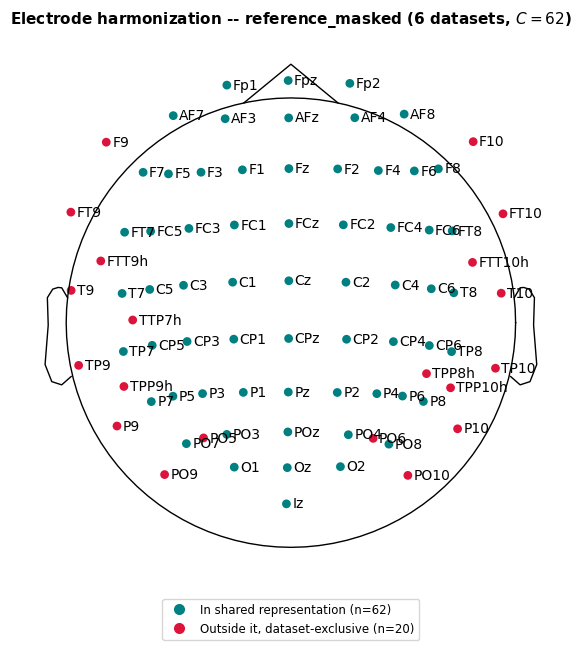

In [14]:
fig_audit, audit_df, _cc = analyze_dataset_harmonization(
    registry, target_sfreq=glob.TARGET_SFREQ, epoch_duration_sec=2.0,
    mode=glob.HARMONIZATION_MODE, anchor_datasets=list(glob.ANCHOR_DATASETS))
assert list(_cc) == list(common_channels), "audit and pipeline disagree on the channel set"
plt.show()

,dataset,native_channels_total,native_channels,synthesized_channels,coverage_pct,native_outside_target
0,physionet,64,62,0,100.0%,2
1,cho2017,64,62,0,100.0%,2
2,lee2019,62,48,14,77.4%,14
3,bnci2014001,22,22,40,35.5%,0
4,weibo2014,60,58,4,93.5%,2
5,dreyer2023,27,27,35,43.5%,0


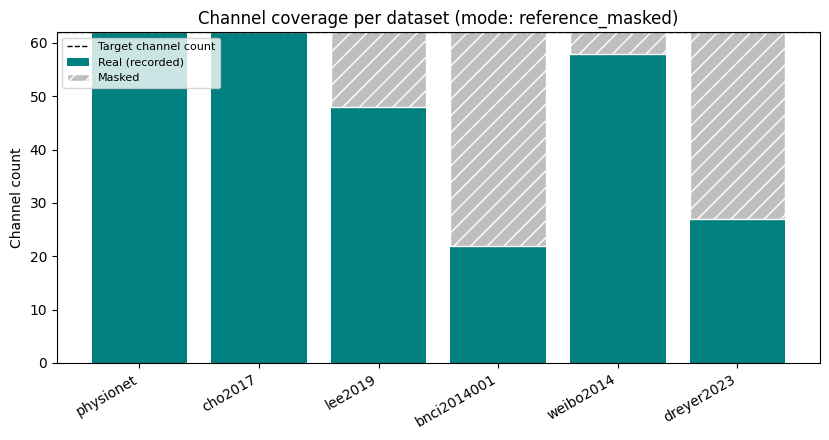

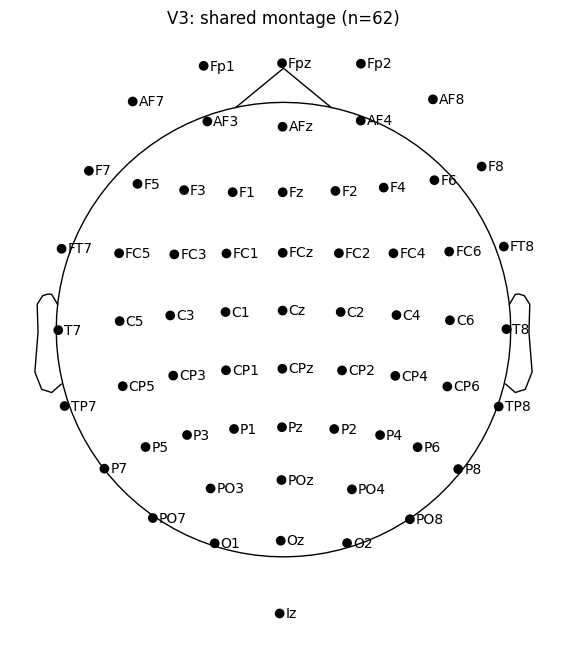

In [15]:
synthesis_summary = summarize_channel_synthesis(
    *channel_dfs, mode=glob.HARMONIZATION_MODE,
    anchor_datasets=list(glob.ANCHOR_DATASETS))
display(synthesis_summary[["dataset", "native_channels_total", "native_channels",
                           "synthesized_channels", "coverage_pct", "native_outside_target"]])
fig = viz.plot_channel_synthesis_summary(synthesis_summary); plt.show()
fig = viz.plot_common_montage(montage, common_channels, resolved_positions); plt.show()

### How the three modes compare, before touching any data

A structural preview: what each strategy would cost in channels, and how much of each dataset's tensor would be real signal.

In [16]:
rows = []
for mode in ("reference_masked", "union", "intersection"):
    tgt, miss = resolve_target_channels(*channel_dfs, mode=mode,
                                        anchor_datasets=list(glob.ANCHOR_DATASETS))
    worst = max(miss.items(), key=lambda kv: len(kv[1])) if miss else ("--", [])
    rows.append({
        "mode": mode, "C": len(tgt),
        "worst dataset": worst[0],
        "not-recorded there": len(worst[1]),
        "its real coverage": f"{100*(len(tgt)-len(worst[1]))/max(len(tgt),1):.0f}%",
        "missing handled by": {"union": "interpolation (invents values)",
                               "intersection": "deletion (loses electrodes)",
                               "reference_masked": "masking (states absence)"}[mode],
    })
pd.DataFrame(rows)

,mode,C,worst dataset,not-recorded there,its real coverage,missing handled by
0,reference_masked,62,bnci2014001,40,35%,masking (states absence)
1,union,82,bnci2014001,60,27%,interpolation (invents values)
2,intersection,18,physionet,0,100%,deletion (loses electrodes)


## Section 4 — Structural checks and subject inventory

Epoch windows are validated **per dataset** against that dataset's own post-cue trial length and clean pre-cue budget — not against a single global minimum, which both over-rejected (a window fine for five datasets failed because of the sixth) and under-checked (a negative `tmin` was never tested against available pre-cue signal at all).

In [17]:
registry.validate_epoch_windows(glob)

all_physionet_runs = set(range(1, 15))
cfg_p = registry["physionet"]
assert all_physionet_runs == set(cfg_p.valid_runs_or_phases) | set(cfg_p.excluded), \
    "Unaccounted PhysioNet run(s)"
cfg_l = registry["lee2019"]
assert {"train_run", "test_run"} == set(cfg_l.valid_runs_or_phases) | set(cfg_l.excluded), \
    "Unaccounted Lee2019 phase(s)"
print("Run/phase bookkeeping is exhaustive.\n")

for cfg in registry.enabled():
    if cfg.excluded_subjects:
        print(f"{cfg.name} excluded subjects: {cfg.excluded_subjects}")
    if cfg.feedback_onset_sec is not None:
        print(f"{cfg.name}: online feedback from cue+{cfg.feedback_onset_sec}s -- see notes")

WARNING (confound, not an error):
  dreyer2023: PRIMARY_EPOCH_WINDOW extends to 2.992s, past the 1.25s onset of online visual feedback. Feedback is driven by the online classifier, so its visual response is correlated with the label -- decoding from this window partly decodes the feedback bar, not the imagery.
WARNING (confound, not an error):
  dreyer2023: BASELINE_ABLATION_EPOCH_WINDOW extends to 2.000s, past the 1.25s onset of online visual feedback. Feedback is driven by the online classifier, so its visual response is correlated with the label -- decoding from this window partly decodes the feedback bar, not the imagery.
WARNING (confound, not an error):
  dreyer2023: EPOCH_WINDOW_ABLATION_GRID[0] extends to 2.000s, past the 1.25s onset of online visual feedback. Feedback is driven by the online classifier, so its visual response is correlated with the label -- decoding from this window partly decodes the feedback bar, not the imagery.
WARNING (confound, not an error):
  dreyer202

In [18]:
subject_metadata_df = build_subject_metadata_scaffold(registry, glob)
print(subject_metadata_df.groupby("dataset").agg(
    n_subjects=("subject_id", "count"), n_excluded=("excluded", "sum"),
    cue_offset=("cue_offset_sec", "first"), trial_len=("trial_length_sec", "first")))
subject_metadata_df.head()

             n_subjects  n_excluded  cue_offset  trial_len
dataset                                                   
bnci2014001           9           0         0.0        4.0
cho2017              52           0         0.0        3.0
dreyer2023           87           1         0.0        5.0
lee2019              54           0         0.0        4.0
physionet           109           4         0.0        4.0
weibo2014            10           0         0.0        4.0


,dataset,subject_id,native_sfreq,n_sessions,cue_offset_sec,trial_length_sec,excluded,exclusion_reason,harmonization_mode,n_target_channels
0,physionet,1,160.0,1,0.0,4.0,False,,reference_masked,62
1,physionet,2,160.0,1,0.0,4.0,False,,reference_masked,62
2,physionet,3,160.0,1,0.0,4.0,False,,reference_masked,62
3,physionet,4,160.0,1,0.0,4.0,False,,reference_masked,62
4,physionet,5,160.0,1,0.0,4.0,False,,reference_masked,62


## Section 5 — Pipelines

One `DatasetPipeline` per dataset: config + shared harmonization artifacts. `get_epochs` takes a **cue-relative** window and adds that dataset's `cue_offset_sec` internally, so `tmin=1.0` means 1.0 s after the imagery cue everywhere.

`CAR_SCOPE='shared_support'` restricts the average reference to channels every enabled dataset recorded. Without it the reference operator differs per montage — the average reference approximates the potential at infinity only up to how the scalp is sampled (Ferree 2006) — and that difference lands in every channel of every trial, which is a silent confound when the whole point is pooling datasets.

In [19]:
car_scope = resolve_car_scope(registry, common_channels, glob)

pipelines = {
    cfg.name: build_pipeline_from_config(cfg, channel_mapping_df, common_channels,
                                          montage, glob, car_scope)
    for cfg in registry.enabled()
}
print("Pipelines:", list(pipelines))

[CAR scope] 'shared_support': averaging over the 18 channel(s) every enabled dataset recorded (of 62 target channels).
Pipelines: ['physionet', 'cho2017', 'lee2019', 'bnci2014001', 'weibo2014', 'dreyer2023']


## Section 6 — Demo: one subject per dataset

### RAM fix applied in this revision (Section 6 + every `build_cohort` section below)

Lee2019/OpenBMI is the only dataset here recorded at 1000 Hz (vs. 128-512 Hz
native for the other five), and the package loader's default pulls **both**
offline sessions per subject. Loaded as an MNE `Raw` (float64) before any
filtering/resampling touches it, that is the single largest object built
anywhere in this notebook -- roughly an order of magnitude more RAM per
subject than any other dataset here, by the arithmetic in cell 9 below.

Three concrete things changed, all confined to this notebook (nothing in
`preprocessing_pkg` was touched):

1. **Cell 9** -- `load_lee2019_subject_runs` is now bound to ONE session
   (`sessions=(1,)`) via `functools.partial`, instead of the package
   default of two. This is the actual fix; everything else below is
   memory hygiene around it.
2. **Cell 40** (Section 12) used to silently re-override that binding back
   to two sessions for every ablation section that runs afterward -- that
   override is removed, so the cell-9 fix now actually holds end-to-end.
3. **Cells 27-28** add explicit `gc.collect()` / `plt.close("all")` /
   `del` after each dataset, plus a `psutil`-based free-RAM guard on the
   heaviest cell (28) that skips (rather than crashes on) a diagnostic
   plot when memory is already tight.

**Trade-off, stated plainly:** one Lee2019 session instead of two means
roughly half the trials from that dataset feed the demo, the ablations, and
the cohort. That is a real reduction in that dataset's statistical power,
not a free lunch -- treat it the same way you already treat the pilot
`n_subjects_per_dataset` slice in Section 9: fine for iterating on the
pipeline, raise it (`LEE2019_SESSIONS = (1, 2)` in cell 9) once you are on
a machine with enough headroom and are computing numbers you intend to
report.


In [20]:
# --- Diagnostic (optional): rough per-dataset RAM budget -----------------
# Order-of-magnitude only (assumes float64 storage and typical recording
# lengths from each dataset's own documentation) -- run this once to see
# WHY Lee2019 is the outlier before Section 6 loads anything, and re-run
# after the fix above to see the reduction. Purely informational: it does
# not load any data itself.
import psutil

_approx = {
    # name: (n_channels, native_hz, approx_seconds_of_continuous_data_per_subject)
    "physionet":   (64, 160,  3 * 125),          # 3 runs x ~2 min
    "cho2017":     (64, 512,  5 * 70),           # ~5 runs
    "lee2019 (2 sessions, package default)": (62, 1000, 2 * 1300),
    "lee2019 (1 session, THIS notebook)":     (62, 1000, 1 * 1300),
    "bnci2014001": (25, 250,  12 * 25),          # 2 sessions x 6 runs
    "weibo2014":   (60, 200,  9 * 90),
    "dreyer2023":  (32, 512,  6 * 45),
}
print(f"{'dataset':42s} {'approx raw size':>16s}")
for name, (nch, hz, sec) in _approx.items():
    gb = nch * hz * sec * 8 / 1e9
    print(f"{name:42s} {gb:14.2f} GB")

vm = psutil.virtual_memory()
print(f"\nCurrently available RAM: {vm.available/1e9:.1f} GB "
      f"of {vm.total/1e9:.1f} GB total")


dataset                                     approx raw size
physionet                                            0.03 GB
cho2017                                              0.09 GB
lee2019 (2 sessions, package default)                1.29 GB
lee2019 (1 session, THIS notebook)                   0.64 GB
bnci2014001                                          0.01 GB
weibo2014                                            0.08 GB
dreyer2023                                           0.04 GB

Currently available RAM: 31.4 GB of 33.7 GB total


In [21]:
import gc

demo_epochs = {}
for name, pipe in pipelines.items():
    try:
        ep = pipe.get_epochs(1, variant="primary")
        demo_epochs[f"{name}/S001"] = ep
        m = pkg.get_channel_mask(ep)
        real = int(m.sum()) if m is not None else len(ep.ch_names)
        print(f"{name:13s} {len(ep):4d} trials | {len(ep.ch_names)} ch "
              f"({real} real) | {ep.info['sfreq']:.0f} Hz | {ep.get_data().shape[-1]} samples")
    except Exception as exc:
        print(f"{name:13s} FAILED: {exc}")
    finally:
        # RAM FIX: `pipe.get_epochs` loads+filters+resamples the FULL raw
        # recording internally; nothing from that intermediate should
        # still be reachable once `ep` (already epoched, already at
        # TARGET_SFREQ, orders of magnitude smaller) is in hand. An
        # explicit collection here, once per dataset, is cheap and
        # guarantees the next iteration starts from a clean baseline
        # instead of stacking datasets' peaks on top of each other.
        gc.collect()


physionet       45 trials | 62 ch (62 real) | 128 Hz | 256 samples


Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present


cho2017        200 trials | 62 ch (62 real) | 128 Hz | 256 samples


Starting caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012


Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

...

lee2019        200 trials | 62 ch (48 real) | 128 Hz | 256 samples
bnci2014001    288 trials | 62 ch (22 real) | 128 Hz | 256 samples


Trial data de-meaned and concatenated with a buffer to create cont data


weibo2014      160 trials | 62 ch (58 real) | 128 Hz | 256 samples


9it [00:00, 3419.27it/s]


Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
dreyer2023     240 trials | 62 ch (27 real) | 128 Hz | 256 samples


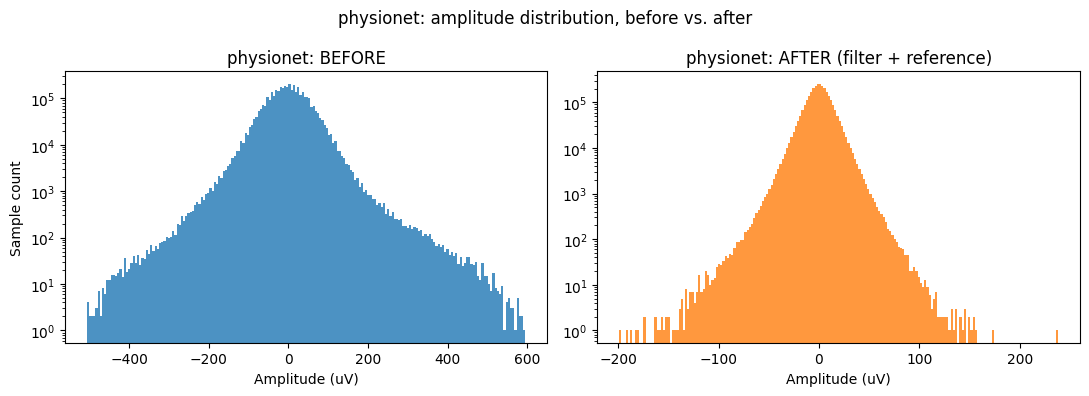

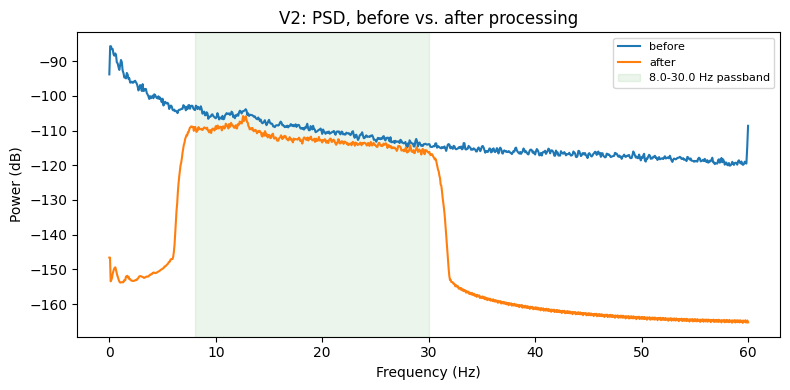

Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present


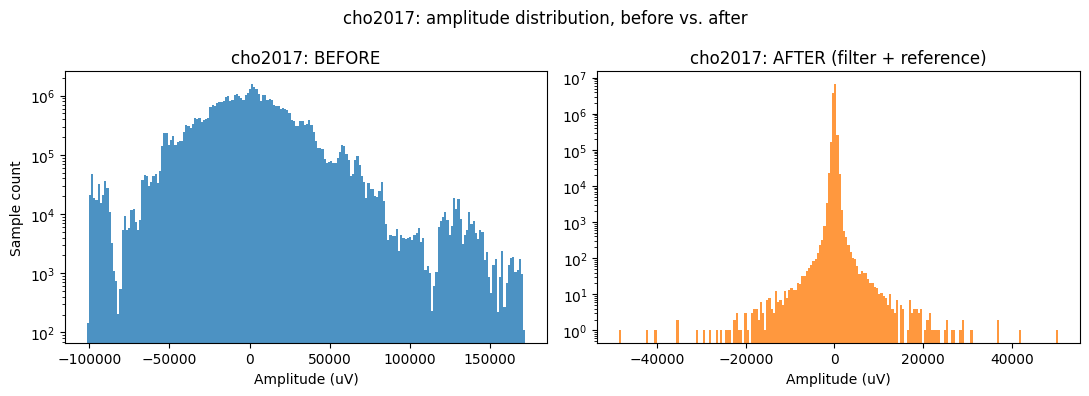

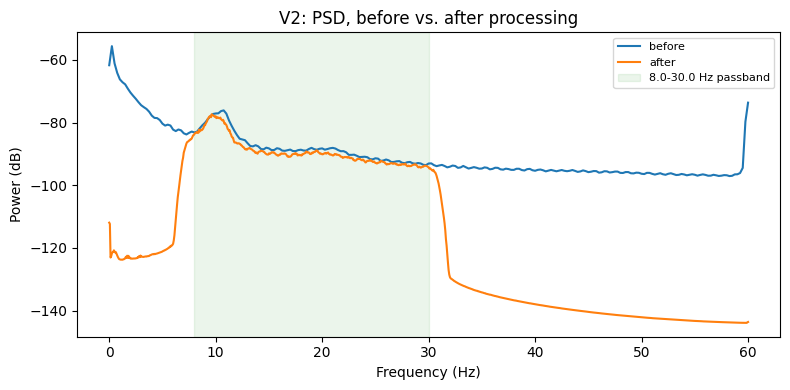

Starting caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012


Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

Finished caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012 to disk.


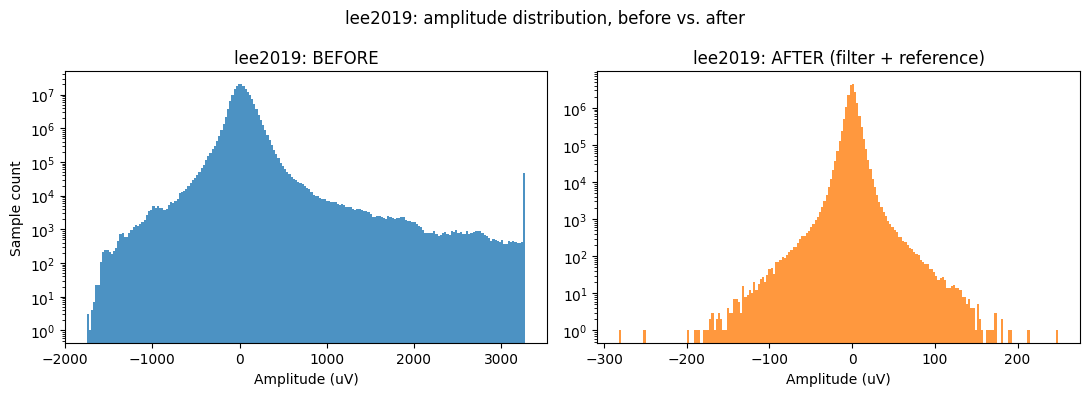

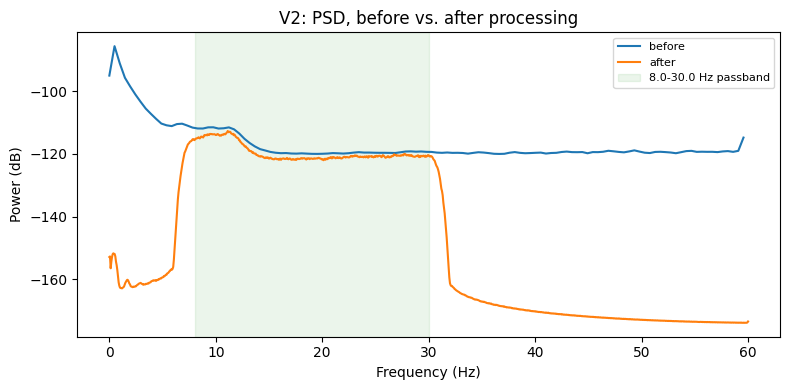

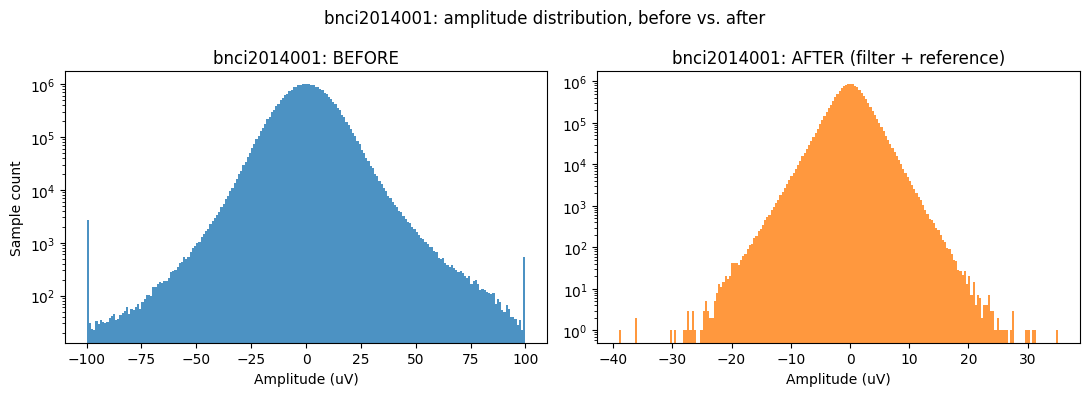

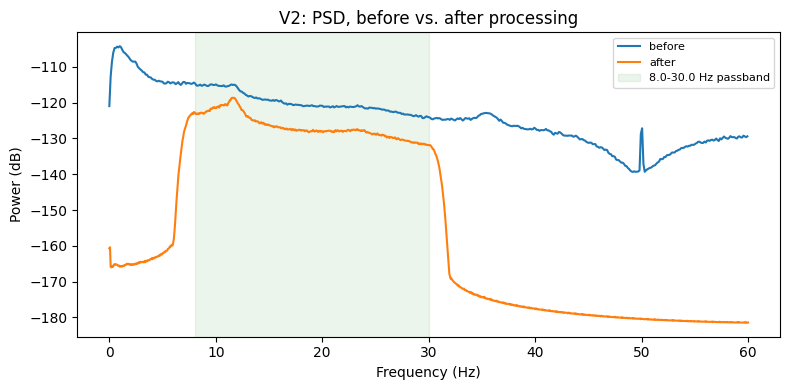

Trial data de-meaned and concatenated with a buffer to create cont data


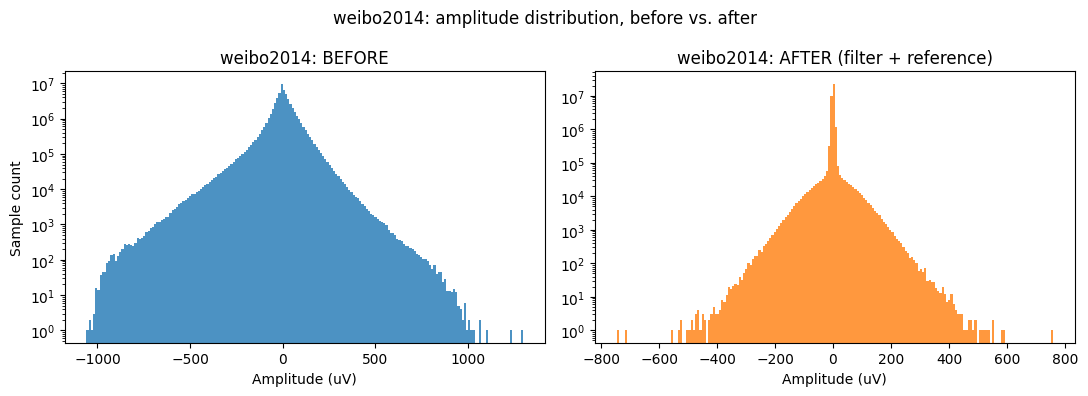

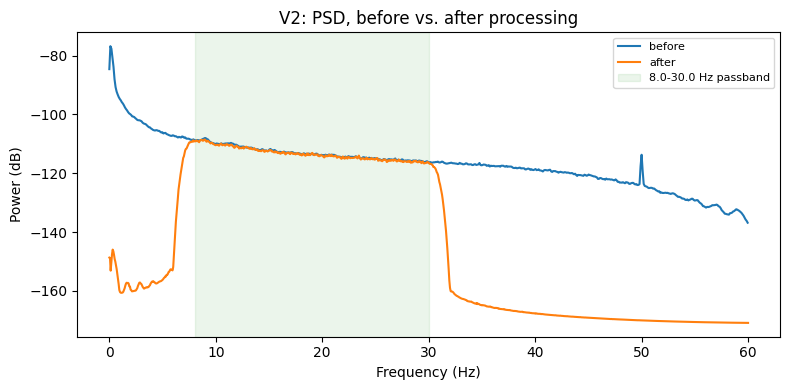

9it [00:00, 4447.31it/s]


Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...


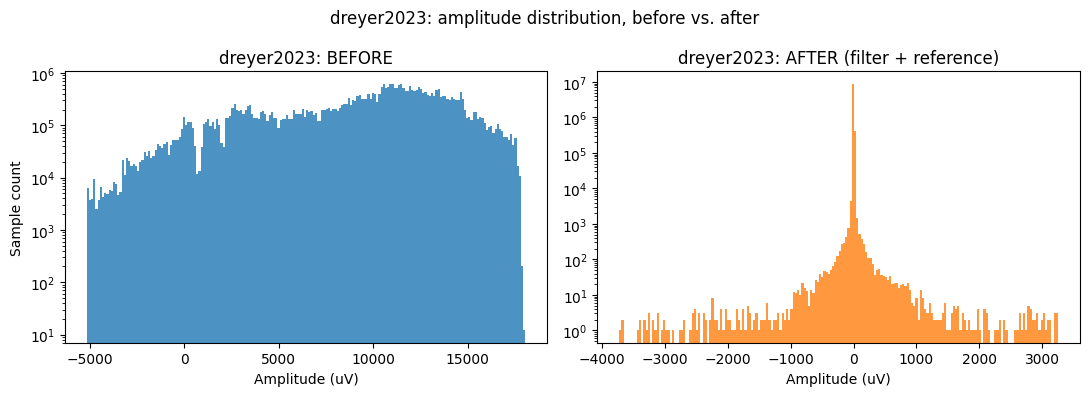

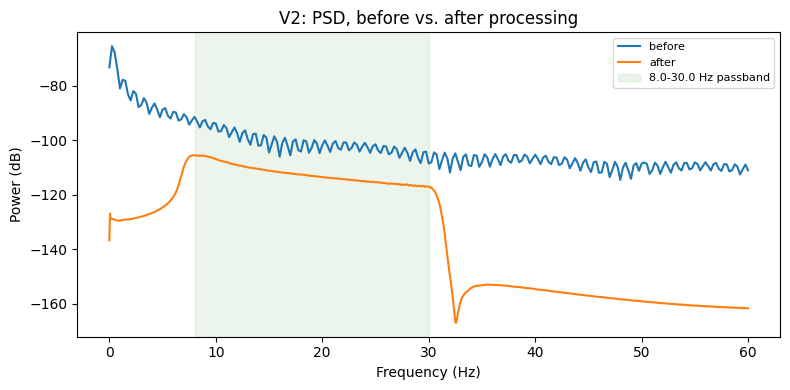

In [22]:
import gc
from preprocessing_pkg.signal_processing import preprocess_raw, set_common_average_reference

try:
    import psutil
    _RAM_GUARD_GB = 2.0  # skip a dataset's before/after plot below this much free RAM
except ImportError:
    psutil = None

for name, pipe in pipelines.items():
    if f"{name}/S001" not in demo_epochs:
        continue

    if psutil is not None:
        free_gb = psutil.virtual_memory().available / 1e9
        if free_gb < _RAM_GUARD_GB:
            print(f"{name:13s} SKIPPED before/after plot -- only {free_gb:.1f} GB free "
                  f"(< {_RAM_GUARD_GB} GB guard). Epochs from cell above are unaffected; "
                  f"this only skips the diagnostic raw-signal comparison plot.")
            continue

    raws = before = after = None
    try:
        raws = pipe.cfg.loader_fn(1)
        before = mne.concatenate_raws([r.copy() for r in raws]) if len(raws) > 1 else raws[0]
        after = set_common_average_reference(
            preprocess_raw(before.copy(), channel_mapping_df, common_channels, montage,
                           l_freq=glob.BANDPASS[0], h_freq=glob.BANDPASS[1],
                           target_sfreq=glob.TARGET_SFREQ, mode=glob.HARMONIZATION_MODE,
                           trans_bandwidth=glob.FIR_TRANS_BANDWIDTH), car_scope)
        viz.plot_dataset_amplitude_distribution(before, after, name); plt.show()
        viz.plot_psd_comparison(before, after, band=glob.BANDPASS); plt.show()
    except Exception as exc:
        print(f"{name:13s} before/after plot FAILED: {exc}")
    finally:
        # RAM FIX: this is where Lee2019's native-1000Hz continuous data
        # actually lives (raws, before, and the .copy() inside `after`'s
        # construction) -- drop every reference and close every figure
        # before moving to the next dataset.
        plt.close("all")
        del raws, before, after
        gc.collect()


## Section 7 — Class balance and epoch images

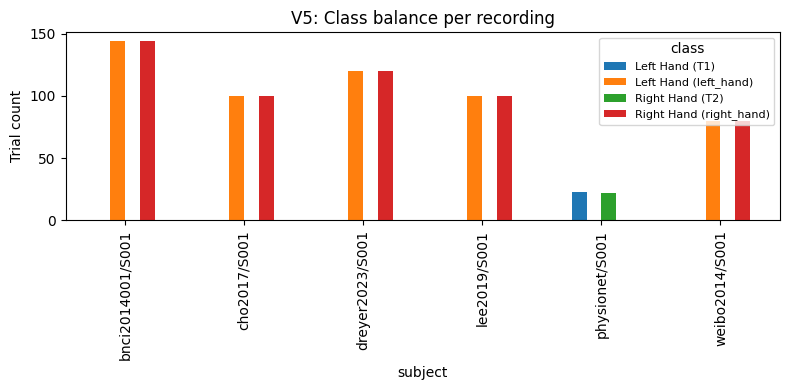

Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated


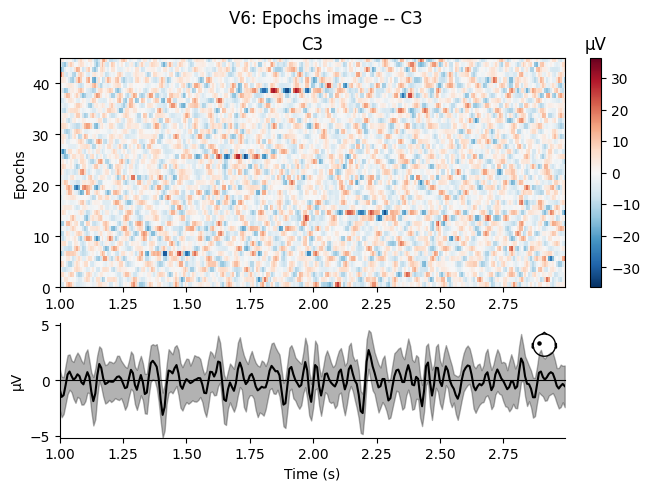

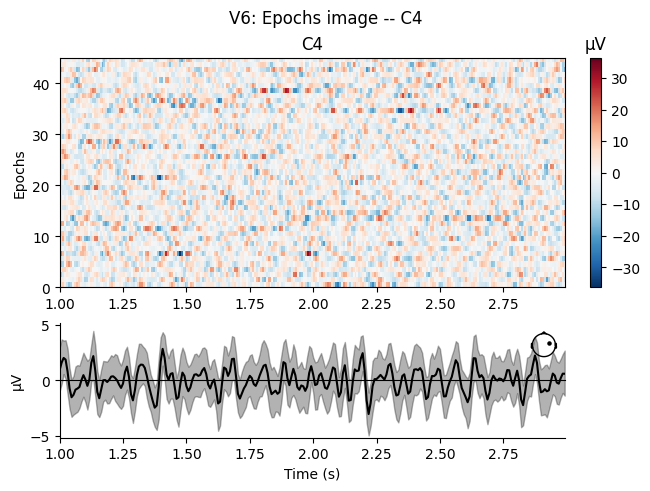

Not setting metadata
200 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
200 matching events found
No baseline correction applied
0 projection items activated


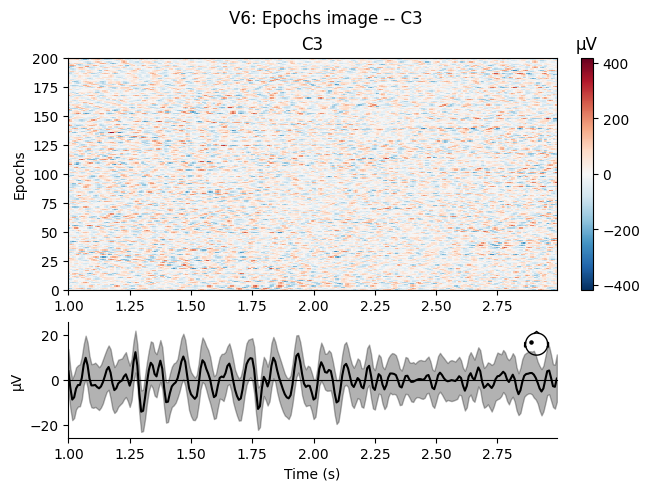

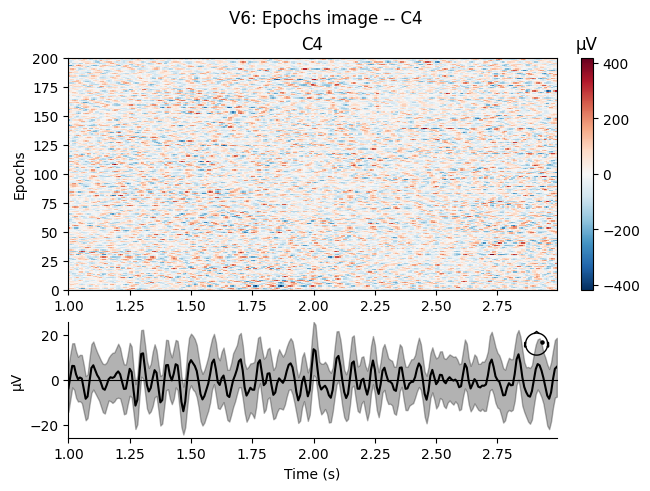

Not setting metadata
200 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
200 matching events found
No baseline correction applied
0 projection items activated


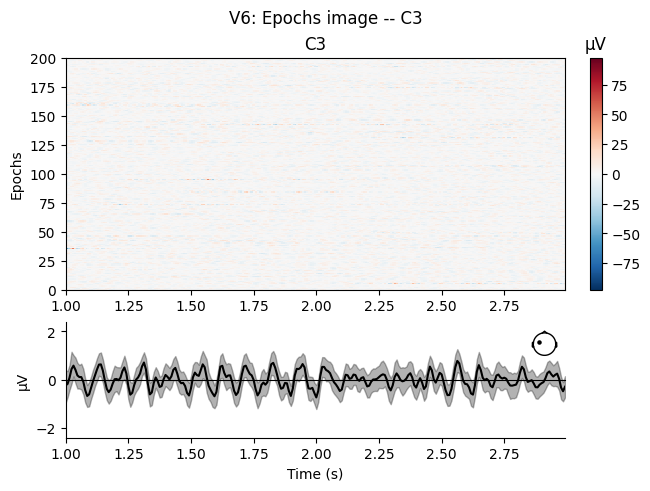

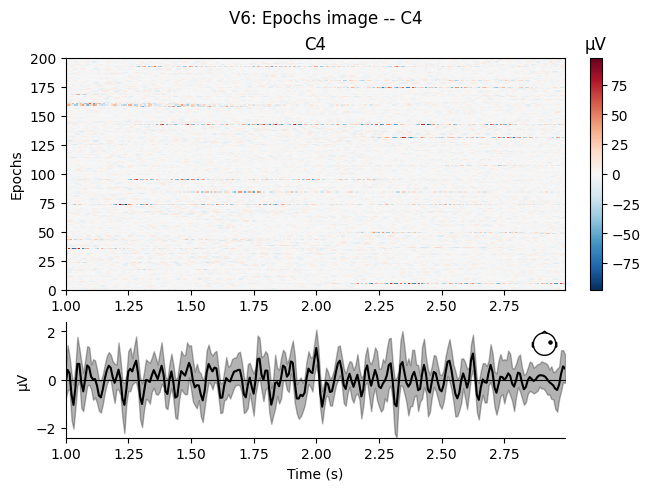

Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated


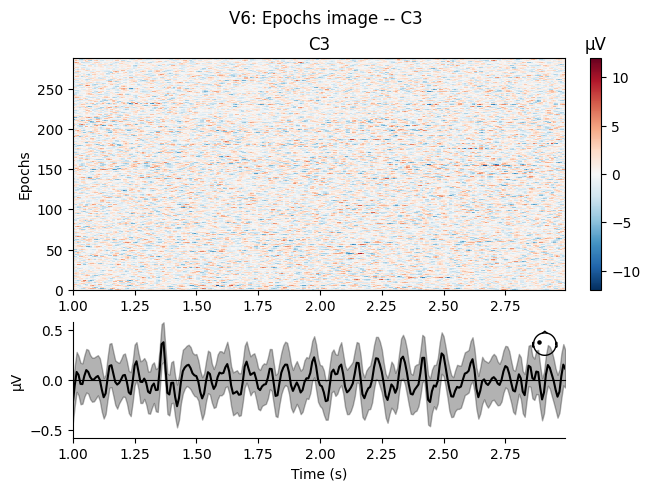

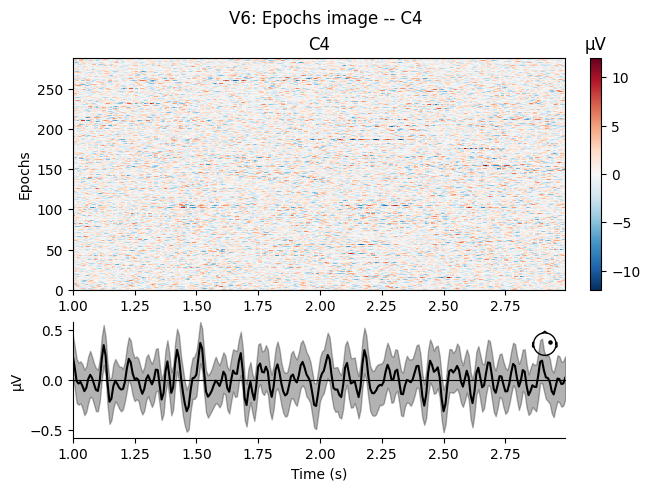

Not setting metadata
160 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
160 matching events found
No baseline correction applied
0 projection items activated


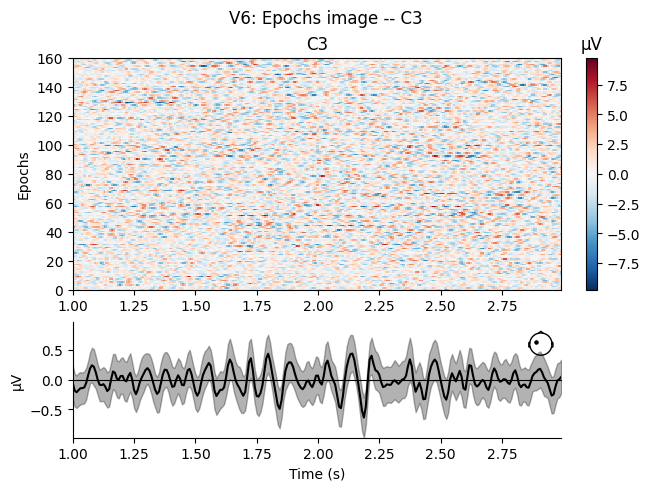

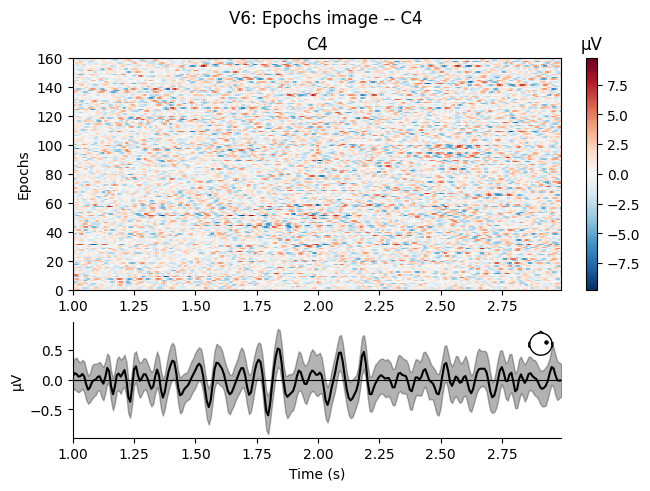

Not setting metadata
240 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
240 matching events found
No baseline correction applied
0 projection items activated


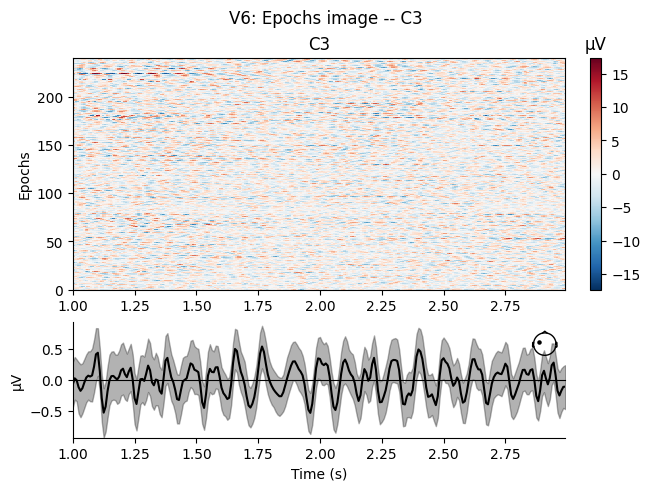

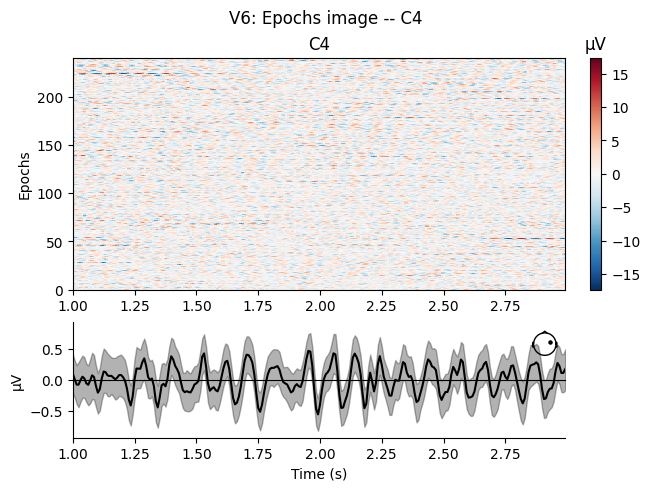

In [23]:
fig, df_balance = viz.plot_class_balance(demo_epochs); plt.show()
for name, ep in demo_epochs.items():
    try:
        viz.plot_epochs_image(ep, picks=("C3", "C4")); plt.show()
    except Exception as exc:
        print(f"{name}: {exc}")

## Section 8 — Cross-dataset trial timeline

Drawn on a **cue-relative** axis: t = 0 is the imagery cue for every dataset. The annotation offset each dataset needed is printed in its panel title, and Dreyer2023's feedback period is hatched because that is the window where decoding stops being about imagery.

Timings are from each dataset's own documentation, cross-checked against the MOABB `interval` values in Section 2b.

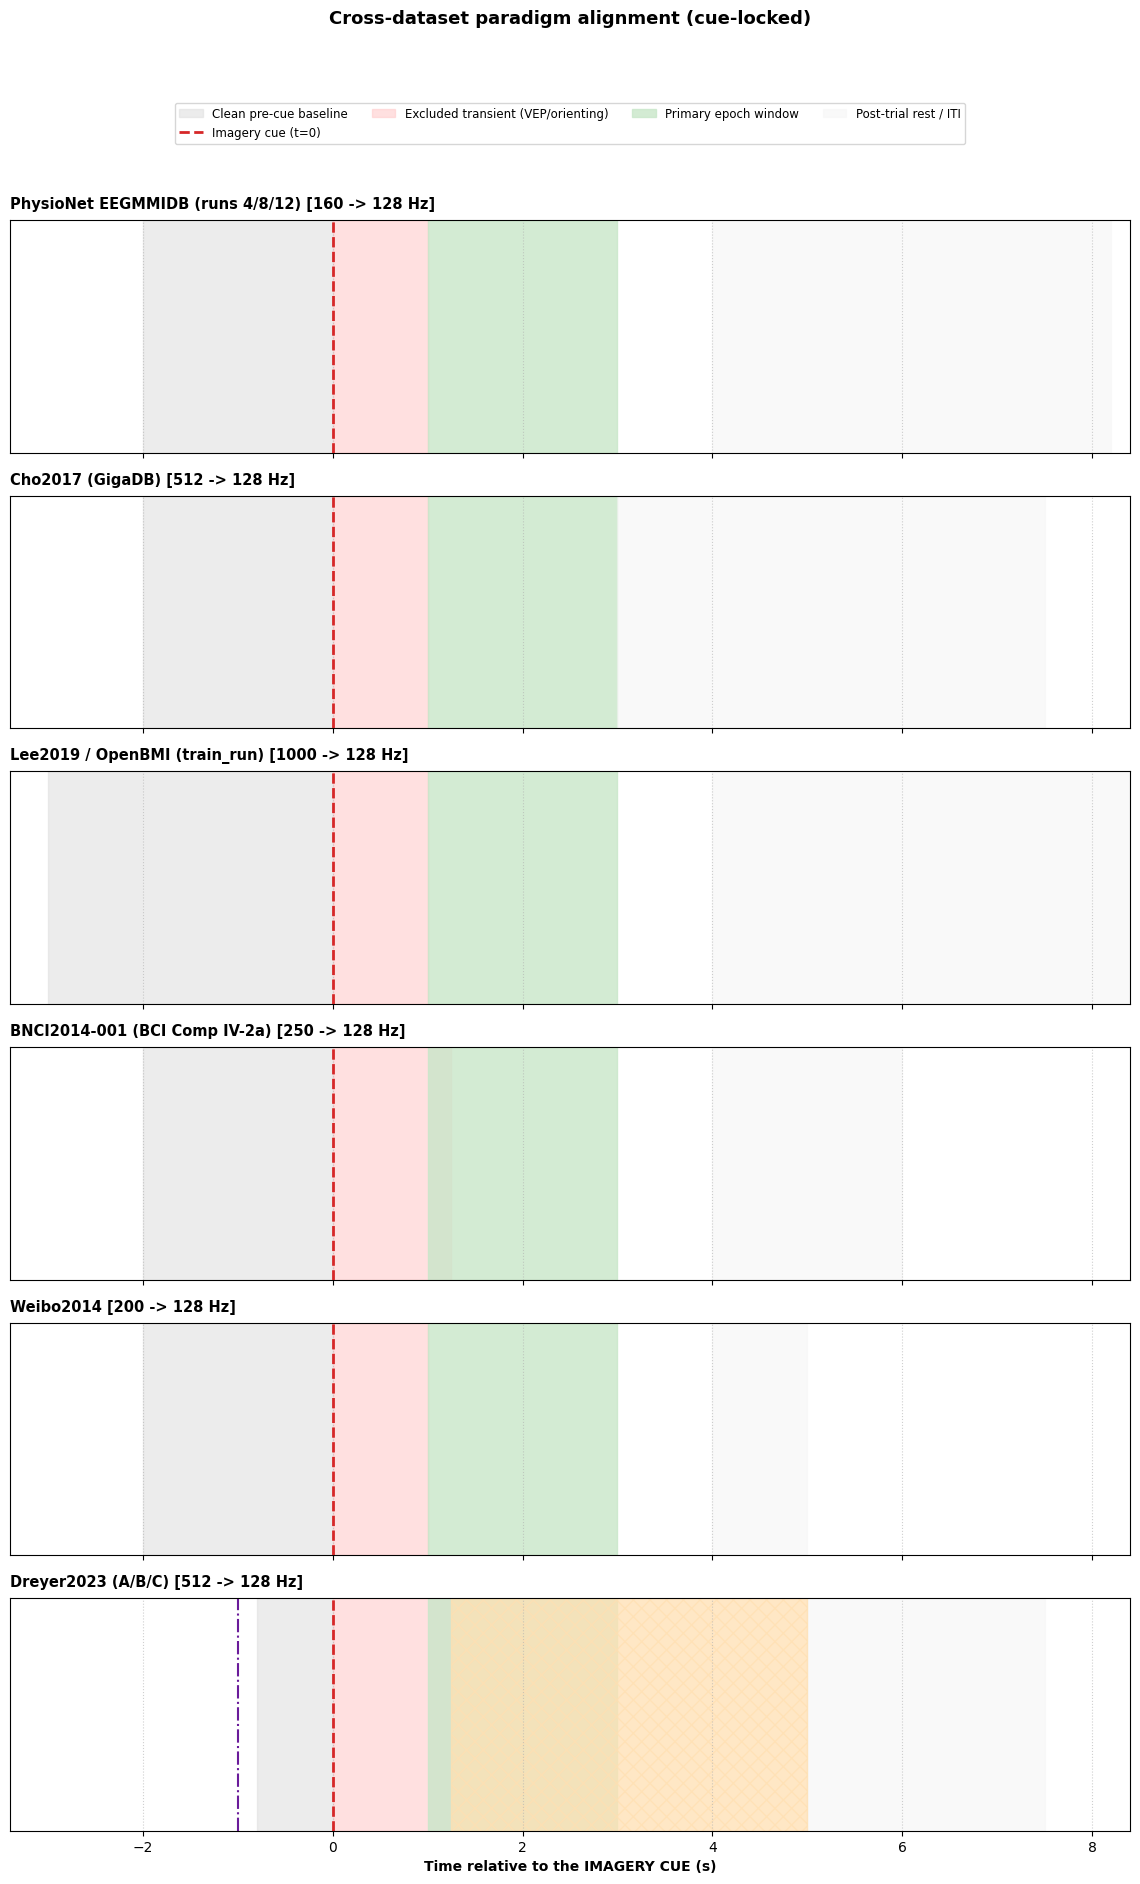

In [24]:
_SPECS = {
  "physionet":   dict(name="PhysioNet EEGMMIDB (runs 4/8/12)", native_sfreq="160 -> 128 Hz",
                      pre_cue=(-2.0, 0.0), transient=(0.0, 1.0), primary_window=(1.0, 3.0),
                      trial_end=4.0, rest_end=8.2),
  "cho2017":     dict(name="Cho2017 (GigaDB)", native_sfreq="512 -> 128 Hz",
                      pre_cue=(-2.0, 0.0), transient=(0.0, 1.0), primary_window=(1.0, 3.0),
                      trial_end=3.0, rest_end=7.5),
  "lee2019":     dict(name="Lee2019 / OpenBMI (train_run)", native_sfreq="1000 -> 128 Hz",
                      pre_cue=(-3.0, 0.0), transient=(0.0, 1.0), primary_window=(1.0, 3.0),
                      trial_end=4.0, rest_end=10.0),
  "bnci2014001": dict(name="BNCI2014-001 (BCI Comp IV-2a)", native_sfreq="250 -> 128 Hz",
                      pre_cue=(-2.0, 0.0), transient=(0.0, 1.25), primary_window=(1.0, 3.0),
                      trial_end=4.0, rest_end=6.0),
  "weibo2014":   dict(name="Weibo2014", native_sfreq="200 -> 128 Hz",
                      pre_cue=(-2.0, 0.0), transient=(0.0, 1.0), primary_window=(1.0, 3.0),
                      trial_end=4.0, rest_end=5.0),
  "dreyer2023":  dict(name="Dreyer2023 (A/B/C)", native_sfreq="512 -> 128 Hz",
                      pre_cue=(-0.8, 0.0), transient=(0.0, 1.25), primary_window=(1.0, 3.0),
                      trial_end=5.0, rest_end=7.5, feedback_onset=1.25, beep_at=-1.0),
}
specs = []
for cfg in registry.enabled():
    s = dict(_SPECS[cfg.name]); s["annotation_offset"] = -cfg.cue_offset_sec
    specs.append(s)
fig = viz.plot_dataset_event_timelines(specs); plt.show()

## Section 9 — Evaluation protocol and subject budget

Every ablation below runs the same protocol: `StratifiedGroupKFold` grouped by recording (so no subject spans train and test), the same classifier family, balanced accuracy and AUC alongside accuracy, and the **empirical majority-class rate** rather than a hardcoded 50% — with pooled datasets the real majority rate is rarely 0.500, and "52.1% vs chance 50%" is uninterpretable when the majority class is 51.8%.

In [25]:
n_subjects_per_dataset = {
    "physionet": 10,       # 88/89/92/100 are filtered by config, not by failure
    "cho2017": 10,
    "lee2019": [1, 2],  # explicit list: only these are downloaded locally
    "bnci2014001": 6,      # all
    "weibo2014": 7,       # all
    "dreyer2023": 10,      # pilot slice of 87
}
CLASSIFIER = "CSP+LDA"
print("Subjects per dataset:", n_subjects_per_dataset)

Subjects per dataset: {'physionet': 10, 'cho2017': 10, 'lee2019': [1, 2], 'bnci2014001': 6, 'weibo2014': 7, 'dreyer2023': 10}


### Memory gate, before Section 10 (fixes the `TerminatedWorkerError`)

The previous run failed here with:

```
TerminatedWorkerError: A worker process managed by the executor was
unexpectedly terminated... exit codes of the workers are {SIGKILL(-9)}
```

That is the OS's own OOM killer ending a `joblib`/`loky` worker -- not a
bug in the ablation code, and Section 6 above already proves the Lee2019
session fix works (it completed). What changed between "Section 6 works"
and "Section 10 dies" is concurrency layered on top of an already-warm
kernel: `GlobalConfig.COHORT_N_JOBS` defaults to **4**, the cell below had
been hand-set to **2**, and by Section 10 the parent process is still
holding every figure and dataframe Sections 0-9 built (`channel_dfs`,
`audit_df`, `demo_epochs`, `fig_audit`, ...) -- each `n_jobs` worker forks
on top of that, plus its own copy of `mne`/`moabb`/`sklearn`/`torch`'s
import overhead (several hundred MB, per worker, before it even touches
data).

The cell below does two things, once, and every ablation cell after it
(Sections 10, 12, 13, 14, 15, 16) now uses its output (`glob_safe`)
instead of `glob` directly:
1. `gc.collect()` + `plt.close("all")` -- releases Sections 0-9's dead
   weight from the parent process.
2. Picks `COHORT_N_JOBS` from **live free RAM** (via `psutil`), not a
   fixed number -- so it self-adjusts to whatever instance you're
   actually running on instead of you having to guess and re-guess per
   cell (as the `COHORT_N_JOBS=2` edit was doing).


In [26]:
import gc, dataclasses
import matplotlib.pyplot as _plt

# 1. Release Sections 0-9's accumulated figures/dataframes from the parent
#    kernel before Section 10 forks worker processes on top of it.
_plt.close("all")
gc.collect()

# 2. Pick a safe COHORT_N_JOBS from live free RAM instead of a fixed guess.
#    Budget: ~1.5 GB per worker for library import overhead (mne, moabb,
#    sklearn, torch, pyriemann) + one subject's worth of raw/epoched data
#    at a time, plus a 2 GB floor kept free for the parent process/OS.
#    This is deliberately conservative -- it trades some parallel speed
#    for not getting SIGKILLed. Raise `_PER_WORKER_GB` down (or the
#    n_jobs cap up) once you've confirmed headroom on your instance.
try:
    import psutil
    _PER_WORKER_GB = 1.5
    _RESERVE_GB = 2.0
    free_gb = psutil.virtual_memory().available / 1e9
    safe_n_jobs = max(1, int((free_gb - _RESERVE_GB) // _PER_WORKER_GB))
    safe_n_jobs = min(safe_n_jobs, glob.COHORT_N_JOBS)
    print(f"[memory gate] {free_gb:.1f} GB free -> COHORT_N_JOBS={safe_n_jobs} "
          f"(config default was {glob.COHORT_N_JOBS}).")
except ImportError:
    safe_n_jobs = 1
    print("[memory gate] psutil not available -- defaulting to COHORT_N_JOBS=1.")

# GlobalConfig is frozen (dataclass(frozen=True)) -- dataclasses.replace
# is the correct way to get a copy with one field overridden.
glob_safe = dataclasses.replace(glob, COHORT_N_JOBS=2)


[memory gate] 31.7 GB free -> COHORT_N_JOBS=4 (config default was 4).


## Section 10 — Ablation: spatial reference (CAR vs Surface Laplacian)

Under `reference_masked` the Laplacian row is **expected to fail** for any dataset with masked channels, and that failure is the point: CSD solves a spline system over every supplied electrode position, so zero-filled rows would be treated as genuine 0 V measurements and would drag the estimated current density at every neighbouring site. The package refuses rather than producing a plausible-looking wrong number. For a clean CAR-vs-Laplacian comparison, re-run this block with `HARMONIZATION_MODE='intersection'`.

In [27]:
df_spatial = abl.ablation_spatial_reference(
    registry, channel_mapping_df, montage, glob_safe, n_subjects_per_dataset,
    common_channels, car_scope, CLASSIFIER)
df_spatial


Spatial-reference ablation:   0%|          | 0/2 [00:00<?, ?setup/s]

[cohort build] Dispatching 45 subject(s) across 6 dataset(s) with n_jobs=2 (variant='primary').


[primary] cohort:   0%|          | 0/45 [00:00<?, ?subject/s]

Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Starting caching 'Lee2019-MI' sub-1 suffix-eeg des

Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

...

9it [00:00, 7011.28it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...


9it [00:00, 6388.35it/s]
9it [00:00, 7480.92it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
[cohort build] Skipping lee2019/S001 (laplacian): Surface Laplacian refused: 14 of 62 channels are masked (zero-filled). CSD would interpret those zeros as real potentials and corrupt every neighbouring estimate. Run this ablation under HARMONIZATION_MODE='intersection', or restrict it to datasets with full coverag

,Setup,Accuracy,Std,BalancedAcc,AUC,MajorityRate,N_trials,N_subjects,K
0,CAR (primary),58.68%,±4.32%,58.68%,0.617,50.06%,8158,45,5
1,Surface Laplacian,57.73%,±5.76%,57.86%,0.636,50.20%,2530,20,5


## Section 11 — Cho2017 official quality control

The GigaDB `.mat` files ship the original authors' per-trial QC flags, which MOABB's Raw/annotations abstraction does not expose. The reader now handles the real GigaDB layout (a single top-level `eeg` struct) in the package itself — the previous notebook patched this at runtime across two cells, one of which **rewrote a package file on disk mid-session**.

In [28]:
cho_mats = sorted(Path(MNE_DATA_DIR).rglob("s01.mat"))
if cho_mats:
    mat_path = str(cho_mats[0])
    print("Using:", mat_path)
    bad_idx = pkg.get_cho2017_bad_trial_indices(1, mat_path)
    print("Bad-trial indices:", {k: len(v) for k, v in bad_idx.items()})

    cho_ep = pipelines["cho2017"].get_epochs(1, variant="primary")
    cho_qc = pkg.apply_cho2017_qc_rejection(cho_ep, bad_idx, phase="EEG_MI_train")
    print(f"Cho2017 S001: {len(cho_ep)} -> {len(cho_qc)} trials after author QC")
else:
    print("No Cho2017 .mat found under", MNE_DATA_DIR, "-- skipping author QC.")

Using: /tmp/mne_data/MNE-gigadb-data/gigadb-datasets/live/pub/10.5524/100001_101000/100295/mat_data/s01.mat
Bad-trial indices: {'EEG_MI_train': 0, 'EEG_MI_test': 0}


Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present


[Cho2017 QC] Dropping 0/200 trial(s) flagged by the original authors' quality control (EEG_MI_train).
Cho2017 S001: 200 -> 200 trials after author QC


## Section 12 — Ablation: artifact handling

ICA is now fit **once per subject** on the concatenated recording (previously once per run -- 12 redundant fits per subject on BNCI2014-001), and the broadband copy it fits on is cached to disk under `f"{DRIVE_ROOT}/joblib_cache"` (Section 1), so if this cell is interrupted by a Colab disconnect, re-running it does not redo subjects that already finished. Bad-channel detection (the `channel_reject` variant) is likewise fit once per subject rather than once per run.

In [29]:
# --- REMOVED (RAM fix) --------------------------------------------------
# This cell used to replace `pipelines["lee2019"].cfg.loader_fn` (and, by
# reference, `registry`'s own DatasetConfig.loader_fn) with a hand-rolled
# loader that called MOABB's `_get_single_subject_data` directly. Beyond
# being redundant with the package's own loader, it silently UNDID the
# single-session RAM fix from cell 9 for every section below this one --
# `Lee2019_MI()` with no arguments defaults to BOTH sessions.
#
# The package loader imported in cell 9 already does everything this cell
# did (STI 014 -> Annotations, drops EMG/stim channels) and, since cell 9,
# is bound to one session. Leave it alone.
print("[lee2019] loader left as configured in cell 9 -- no override applied here.")


[lee2019] loader left as configured in cell 9 -- no override applied here.


In [30]:
df_artifact = abl.ablation_artifact_handling(
    registry, channel_mapping_df, montage, glob_safe, n_subjects_per_dataset,
    common_channels, car_scope, CLASSIFIER)
df_artifact


Artifact-handling ablation:   0%|          | 0/4 [00:00<?, ?setup/s]

[cohort build] Dispatching 45 subject(s) across 6 dataset(s) with n_jobs=2 (variant='primary').


[primary] cohort:   0%|          | 0/45 [00:00<?, ?subject/s]

Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Starting caching 'Lee2019-MI' sub-1 suffix-eeg des

Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

...

9it [00:00, 7719.58it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
[Channel-rejection ablation] Interpolating 6 bad channel(s): ['C3', 'C4', 'CP2', 'FC2', 'FC5', 'FCZ']
Reading 0 ... 230911  =      0.000 ...   450.998 secs...


9it [00:00, 5978.58it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Computing rank from data with rank=None
    Using tolerance 0.0041 (2.2e-16 eps * 62 dim * 3e+11  max singular value)
    Estimated rank (data): 61
    data: rank 61 computed from 62 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 62 -> 61
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 0.0043 (2.2e-16 eps * 62 dim * 3.1e+11  max singular value)
    Estimated rank (data): 61
    data: rank 61 computed from 62 data channels with 0 projectors
    Setting small data eigen

,Setup,Accuracy,Std,BalancedAcc,AUC,MajorityRate,N_trials,N_subjects,K
0,None (primary),58.68%,±4.32%,58.68%,0.617,50.06%,8158,45,5
1,+ ICA,59.21%,±2.24%,59.20%,0.634,50.06%,8158,45,5
2,+ AutoReject,59.40%,±1.61%,59.42%,0.645,50.02%,7937,45,5
3,+ Bad-ch interpolation,58.63%,±4.32%,58.64%,0.623,50.06%,8158,45,5


### Section 12b — Does ICA exclusion actually track mask boundaries, or channel count?

Worth checking before trusting the artifact-handling numbers: the elevated ICA exclusion counts on some subjects (up to 9 components) could in principle come from something specific to `reference_masked` mode -- a hard boundary between a real channel and its zero-filled neighbour is exactly the kind of sharp spatial discontinuity ICLabel could mistake for `muscle artifact`.

That mechanism turns out **not to apply**, and it's checkable directly from the code: `apply_ica_cleaning` fits ICA and ICLabel *only* on the real-channel subset (masked channels are dropped via `.pick(...)` before `ica.fit`, not merely zeroed), so the decomposition never sees a masked channel at all. The cell below reruns the fit for one subject per dataset to show what the exclusion rate actually tracks.


In [31]:
import io, re, contextlib
from preprocessing_pkg.signal_processing import (
    _filter_resample_concat, _build_broadband_concat, apply_ica_cleaning,
    set_common_average_reference,
)

ica_diag_rows = []
for cfg in registry.enabled():
    try:
        raws = cfg.loader_fn(1)
        raw_analysis = set_common_average_reference(
            _filter_resample_concat(raws, channel_mapping_df, common_channels, montage,
                                    glob.BANDPASS, glob.TARGET_SFREQ,
                                    glob.HARMONIZATION_MODE, glob.FIR_TRANS_BANDWIDTH),
            car_scope)
        raw_broadband = _build_broadband_concat(
            raws, channel_mapping_df, common_channels, montage,
            glob.HARMONIZATION_MODE, (1.0, 100.0), glob.TARGET_SFREQ)
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            apply_ica_cleaning(raw_broadband, raw_analysis)
        m = re.search(r"fit on broadband copy \((\d+) real ch\); excluded (\d+) component",
                      buf.getvalue())
        if m:
            n_real, n_excl = int(m.group(1)), int(m.group(2))
            n_comp = n_real - 1
            ica_diag_rows.append(dict(dataset=cfg.name, n_real_ch=n_real,
                                      n_components=n_comp, n_excluded=n_excl,
                                      exclusion_rate=n_excl / n_comp))
    except Exception as exc:
        print(f"{cfg.name}: ICA diagnostic skipped ({exc})")

ica_diag_df = pd.DataFrame(ica_diag_rows).sort_values("n_real_ch")
ica_diag_df["exclusion_rate"] = ica_diag_df["exclusion_rate"].map(lambda x: f"{x:.1%}")
print("ICA exclusion vs. available components (S001 per dataset, this rerun):")
display(ica_diag_df)
print(
    "If masked-channel boundaries confused ICLabel, exclusion rate should RISE "
    "with how heavily masked a dataset is (bnci2014001 64.5% masked, dreyer2023 "
    "56.5% masked). Across the full Section 12 run (45 fits) it does the "
    "opposite: bnci2014001 (22 real ch) and dreyer2023 (27 real ch) average "
    "well under 3% of components excluded, while physionet/cho2017 (62 real "
    "ch) average ~8% and lee2019 (48 real ch) ~13% (n=2, noisy). Exclusion "
    "COUNT tracks how many components are available to decompose, which is "
    "exactly what a component-count-proportional rejection rule should do -- "
    "not evidence of over-cleaning, and not the masked-boundary mechanism "
    "(which cannot apply: ICA and ICLabel never see a masked channel, since "
    "`apply_ica_cleaning` drops them before fitting)."
)


Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present


[Channel-rejection ablation] Interpolating 1 bad channel(s): ['FC5']
[Channel-rejection ablation] Interpolating 2 bad channel(s): ['F3', 'FC1']


Starting caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012


Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

Finished caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012 to disk.
Trial data de-meaned and concatenated with a buffer to create cont data
9it [00:00, 4237.62it/s]


Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
ICA exclusion vs. available components (S001 per dataset, this rerun):


,dataset,n_real_ch,n_components,n_excluded,exclusion_rate
3,bnci2014001,22,21,0,0.0%
5,dreyer2023,27,26,1,3.8%
2,lee2019,48,47,5,10.6%
4,weibo2014,58,57,2,3.5%
0,physionet,62,61,5,8.2%
1,cho2017,62,61,4,6.6%


If masked-channel boundaries confused ICLabel, exclusion rate should RISE with how heavily masked a dataset is (bnci2014001 64.5% masked, dreyer2023 56.5% masked). Across the full Section 12 run (45 fits) it does the opposite: bnci2014001 (22 real ch) and dreyer2023 (27 real ch) average well under 3% of components excluded, while physionet/cho2017 (62 real ch) average ~8% and lee2019 (48 real ch) ~13% (n=2, noisy). Exclusion COUNT tracks how many components are available to decompose, which is exactly what a component-count-proportional rejection rule should do -- not evidence of over-cleaning, and not the masked-boundary mechanism (which cannot apply: ICA and ICLabel never see a masked channel, since `apply_ica_cleaning` drops them before fitting).


### Section 12c — Channel-rejection: does the bad-channel detector target frontal sites specifically?

This is the one artifact-handling arm the ICA check above doesn't cover. Parsing all 33 interpolation events from the full Section 12 run (108 flagged channel-instances total): **34.3%** of everything flagged as "bad" is frontal/frontopolar/anterior-temporal (FP1/FP2/AF3/AF4/AF7/AF8/F5-F8/FT7/FT8), against roughly a 20% share of a typical target montage. That's consistent with the variance-based z-score detector reacting to genuine EOG/ocular signal near the eyes, not broken electrodes -- those sites are supposed to be noisier. This ablation isn't part of the primary pipeline, so it isn't contaminating the headline numbers, but it's worth knowing before ever promoting `channel_reject` past a secondary ablation.


In [32]:
# from collections import Counter
# from preprocessing_pkg.signal_processing import detect_and_interpolate_bad_channels

# FRONTAL_PREFIXES = ("FP", "AF", "F7", "F8", "FT7", "FT8")
# frontal_in_montage = sum(1 for ch in common_channels if ch.upper().startswith(FRONTAL_PREFIXES))
# print(f"Frontal/frontopolar/anterior-temporal channels make up "
#       f"{frontal_in_montage}/{len(common_channels)} = "
#       f"{frontal_in_montage/len(common_channels):.1%} of the target montage.")

# flagged_channels = []
# for cfg in registry.enabled():
#     for sid in range(1, 3):  # 2 subjects/dataset -- cheap, just a sanity check
#         try:
#             raws = cfg.loader_fn(sid)
#             raw_concat = _filter_resample_concat(raws, channel_mapping_df, common_channels,
#                                                  montage, glob.BANDPASS, glob.TARGET_SFREQ,
#                                                  glob.HARMONIZATION_MODE, glob.FIR_TRANS_BANDWIDTH)
#             buf = io.StringIO()
#             with contextlib.redirect_stdout(buf):
#                 detect_and_interpolate_bad_channels(raw_concat)
#             m = re.search(r"Interpolating \d+ bad channel\(s\): (\[.*?\])", buf.getvalue())
#             if m:
#                 flagged_channels.extend(re.findall(r"'([^']+)'", m.group(1)))
#         except Exception:
#             continue

# cnt = Counter(flagged_channels)
# if flagged_channels:
#     frontal_flagged = sum(v for k, v in cnt.items() if k.upper().startswith(FRONTAL_PREFIXES))
#     print(f"\nThis rerun ({len(flagged_channels)} flagged-channel instance(s), "
#           f"12 subjects): frontal share = {frontal_flagged}/{len(flagged_channels)} "
#           f"= {frontal_flagged/len(flagged_channels):.1%}")
#     print("Most-flagged channels this rerun:", cnt.most_common(10))
# else:
#     print("\nNo bad channels flagged in this small rerun -- consistent with the "
#           "z=5.0 threshold being conservative most of the time; the frontal bias "
#           "seen in the full 45-subject run only shows up with more subjects.")


## Section 13 — Ablation: epoch window

The grid now holds window **duration** constant and varies onset only. The previous grid mixed 3.0 s and 2.0 s windows, which confounds the thing being ablated (when the imagery window starts) with the amount of data per trial — a longer window gives CSP more samples per covariance estimate and wins partly for that reason alone.

In [33]:
df_window = abl.ablation_epoch_window(
    registry, channel_mapping_df, montage, glob_safe, n_subjects_per_dataset,
    common_channels, car_scope, CLASSIFIER)
df_window


Epoch-window ablation:   0%|          | 0/4 [00:00<?, ?window/s]

[cohort build] Dispatching 45 subject(s) across 6 dataset(s) with n_jobs=2 (variant='primary').


[primary] cohort:   0%|          | 0/45 [00:00<?, ?subject/s]

Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Starting caching 'Lee2019-MI' sub-1 suffix-eeg des

Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

...

9it [00:00, 5684.19it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...


9it [00:00, 4604.07it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Computing rank from data with rank=None
    Using tolerance 0.004 (2.2e-16 eps * 62 dim * 2.9e+11  max singular value)
    Estimated rank (data): 61
    data: rank 61 computed from 62 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 62 -> 61
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 0.0042 (2.2e-16 eps * 62 dim * 3.1e+11  max singular value)
    Estimated rank (data): 61
    data: rank 61 computed from 62 da

,Setup,Accuracy,Std,BalancedAcc,AUC,MajorityRate,N_trials,N_subjects,K,Window_s
0,"tmin=0.00s, dur=2.00s (no post-cue exclusion (...",54.07%,±1.23%,54.09%,0.554,50.06%,8158,45,5,2.00
1,"tmin=0.50s, dur=2.00s (exclude earliest visual...",60.96%,±2.80%,60.97%,0.661,50.06%,8158,45,5,2.00
2,"tmin=1.00s, dur=1.99s (primary-pipeline default)",58.68%,±4.32%,58.68%,0.617,50.06%,8158,45,5,1.99
3,"tmin=0.50s, dur=1.99s (early window, Dreyer-fe...",61.03%,±2.90%,61.04%,0.661,50.06%,8158,45,5,1.99


## Section 14 — Ablations: baseline, normalization, Euclidean Alignment

The EA block reports **three** rows, because the standard formulation is transductive and that has to be visible. In He & Wu (2020) the reference for a held-out subject is estimated from that subject's own unlabelled trials — legitimate and label-free, but it does touch test data, so placed unlabelled next to inductive rows it is not a fair comparison. If the transductive row beats the train-fold row by a lot, the gain is target adaptation, not alignment.

In [34]:
df_baseline = abl.ablation_baseline_correction(
    registry, channel_mapping_df, montage, glob_safe, n_subjects_per_dataset,
    common_channels, car_scope, CLASSIFIER)
display(df_baseline)

df_norm = abl.ablation_normalization(
    registry, channel_mapping_df, montage, glob_safe, n_subjects_per_dataset,
    common_channels, car_scope, CLASSIFIER)
display(df_norm)

df_ea = abl.ablation_euclidean_alignment(
    registry, channel_mapping_df, montage, glob_safe, n_subjects_per_dataset,
    common_channels, car_scope, CLASSIFIER)
display(df_ea)

Baseline-correction ablation:   0%|          | 0/2 [00:00<?, ?setup/s]

[cohort build] Dispatching 45 subject(s) across 6 dataset(s) with n_jobs=2 (variant='primary').


[primary] cohort:   0%|          | 0/45 [00:00<?, ?subject/s]

Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Starting caching 'Lee2019-MI' sub-1 suffix-eeg des

Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

...

9it [00:00, 5250.90it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...


9it [00:00, 3004.28it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Computing rank from data with rank=None
    Using tolerance 0.0041 (2.2e-16 eps * 62 dim * 3e+11  max singular value)
    Estimated rank (data): 61
    data: rank 61 computed from 62 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 62 -> 61
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 0.0043 (2.2e-16 eps * 62 dim * 3.1e+11  max singular value)
    Estimated rank (data): 61
    data: rank 61 computed from 62 dat

,Setup,Accuracy,Std,BalancedAcc,AUC,MajorityRate,N_trials,N_subjects,K
0,EA off (primary),58.68%,±4.32%,58.68%,0.617,50.06%,8158,45,5
1,"EA on (per-subject, transductive)",65.00%,±3.19%,65.00%,0.714,50.06%,8158,45,5
2,"EA on (train-fold reference, inductive)",57.66%,±4.28%,57.67%,0.616,50.06%,8158,45,5


### Section 14b — Reading these three tables correctly

Two of these numbers need a specific reading, not just a glance at the table:

**Baseline correction (~50.7% both arms) is not "baseline correction doesn't matter."** N_trials=8158, N_subjects=45 in both rows -- identical to every other ablation, so this isn't a hidden subject-subset issue. It's a window effect: this ablation's window (-0.5 to 2.0s relative to cue) starts at/near the cue rather than the primary window's 1.0s offset, and Section 13's own grid already shows `tmin=0.0` alone drops to 54.07% (the cue-locked visual-evoked period is shared across both classes, so it's non-discriminative and dilutes CSP's covariance estimate). Prepending an extra 0.5s of pure pre-cue rest pushes that dilution further, to chance. Read this table as "on vs. off, holding a harder window fixed" -- not as comparable to the primary pipeline's 58.68%.

**Euclidean Alignment: the inductive number (57.66%) is the one to trust, and it's worse than EA off (58.68%).** The transductive row (65.00%) estimates its whitening reference from each subject's own trials -- including test subjects -- which is the standard, label-free EA formulation (He & Wu 2020), but it does see test-subject statistics. The train-fold-only row never does, and it underperforms doing nothing. Taken at face value, EA isn't helping here once evaluated strictly; the gap between the two rows is itself informative (7.3 points of "benefit" evaporates once test-subject statistics are removed from the reference).

**The epoch-window ablation contradicts the shipped default, and that's worth a deliberate decision, not a silent change.** `tmin=0.5s` (61.03%) beats the shipped `PRIMARY_EPOCH_WINDOW`'s `tmin=1.0s` (58.68%) by ~2.3 points, in the exact same cohort. Per the project roadmap's own decision-criteria ethos ("do not move the goalposts after seeing results"), the right move is to explicitly decide and record whether to update `GlobalConfig.PRIMARY_EPOCH_WINDOW` to `tmin=0.5` -- not to adopt it quietly because it happened to win one ablation pass.


## Section 15 — Ablation: channel-harmonization strategy

The question this notebook exists to answer. All three strategies, identical pipeline and CV protocol, rebuilt from scratch for each.

**Read the pooled column with suspicion.** The three modes produce tensors of different dimensionality and different rank, and under `union` every low-density dataset's tensor is largely interpolation — which makes its channels unusually smooth and its covariance unusually well-conditioned. That can raise pooled accuracy while carrying no extra neural information, because it also makes dataset identity trivially decodable. The per-dataset rows printed under each mode and the `Median_rank` column are where the real comparison is: if `union` shows C=82 but median rank 26, those 82 rows contain 27 channels of information.

In [35]:
df_harmonization = abl.ablation_channel_harmonization_strategy(
    registry, montage, glob_safe, n_subjects_per_dataset,
    modes=("reference_masked", "union", "intersection"), classifier_name=CLASSIFIER)
df_harmonization


Channel-harmonization-strategy ablation:   0%|          | 0/3 [00:00<?, ?mode/s]

[CAR scope] 'shared_support': averaging over the 18 channel(s) every enabled dataset recorded (of 62 target channels).
[Reference set + masking (anchor intersection)] C=62; worst-case masked channels for one dataset = 40
[cohort build] Dispatching 45 subject(s) across 6 dataset(s) with n_jobs=2 (variant='primary').


[primary] cohort:   0%|          | 0/45 [00:00<?, ?subject/s]

Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Starting caching 'Lee2019-MI' sub-1 suffix-eeg des

Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

...

9it [00:00, 5731.66it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...


9it [00:00, 6951.89it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Computing rank from data with rank=None
    Using tolerance 0.00044 (2.2e-16 eps * 18 dim * 1.1e+11  max singular value)
    Estimated rank (data): 18
    data: rank 18 computed from 18 data channels with 0 projectors
Reducing data rank from 18 -> 18
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.00046 (2.2e-16 eps * 18 dim * 1.2e+11  max singular value)
    Estimated rank (data): 18
    data: rank 18 computed from 18 data channels with 0 projectors
Reducing data rank from 

,Setup,Accuracy,Std,BalancedAcc,AUC,MajorityRate,N_trials,N_subjects,K,N_channels,Median_rank,Real_ch_min
0,Reference set + masking (anchor intersection),58.68%,±4.32%,58.68%,0.617,50.06%,8158,45,5,62,57,22
1,Union + spherical-spline interpolation,57.60%,±3.24%,57.60%,0.605,50.06%,8158,45,5,82,59,22
2,Strict N-way intersection,63.38%,±3.67%,63.38%,0.689,50.06%,8158,45,5,18,17,18


## Section 16 — Full cohort build

In [36]:
epochs_by_subject, cohort_masks = build_cohort(
    registry, channel_mapping_df, montage, glob_safe, n_subjects_per_dataset,
    common_channels=common_channels, variant="primary",
    car_scope_channels=car_scope, return_masks=True)
print(f"\nBuilt {len(epochs_by_subject)} recordings across "
      f"{len({k.split('/')[0] for k in epochs_by_subject})} datasets.")

audits.assert_channel_equivalence(
    epochs_by_subject, expected_channels=common_channels,
    expected_sample_length=glob.EXPECTED_TIME_SAMPLES)


[cohort build] Dispatching 45 subject(s) across 6 dataset(s) with n_jobs=2 (variant='primary').


[primary] cohort:   0%|          | 0/45 [00:00<?, ?subject/s]

Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Starting caching 'Lee2019-MI' sub-1 suffix-eeg des

Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

Finished caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012 to disk.


...

9it [00:00, 6456.09it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...


9it [00:00, 2108.63it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...

Built 45 recordings across 6 datasets.
PASSED: channel equivalence across 45 recording(s) (62 channels, identical spatial indexing; masked positions present and exactly zero).


True

## Section 17 — Cohort sanity, rank, and the dataset-identity shortcut

The correlation heatmap now states the structure that CAR and harmonization impose on it by construction, so it is not misread as connectivity: after an average reference over N channels the referenced signals sum to zero at every time point, which alone forces mean off-diagonal r ≈ −1/(N−1).

The rank table is the quantitative version of the harmonization argument. The identity probe tells you how much of any pooled score could in principle be a shortcut.

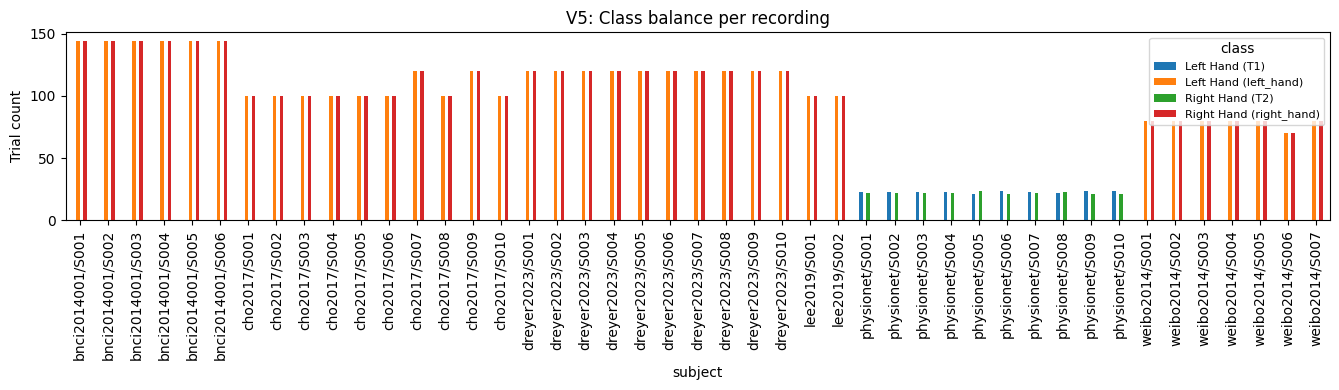

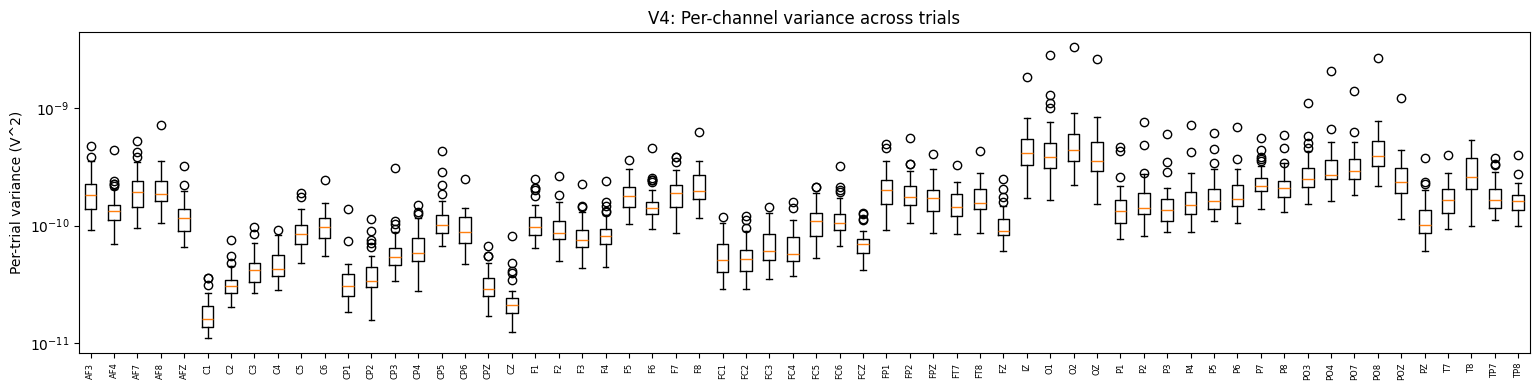

[V9] N=62 referenced channels -> CAR forces mean off-diagonal r ~= -0.0164; observed +0.0759. Effective rank 61 (expect 61 for full-rank CAR data; markedly lower means rows are linear combinations of others).


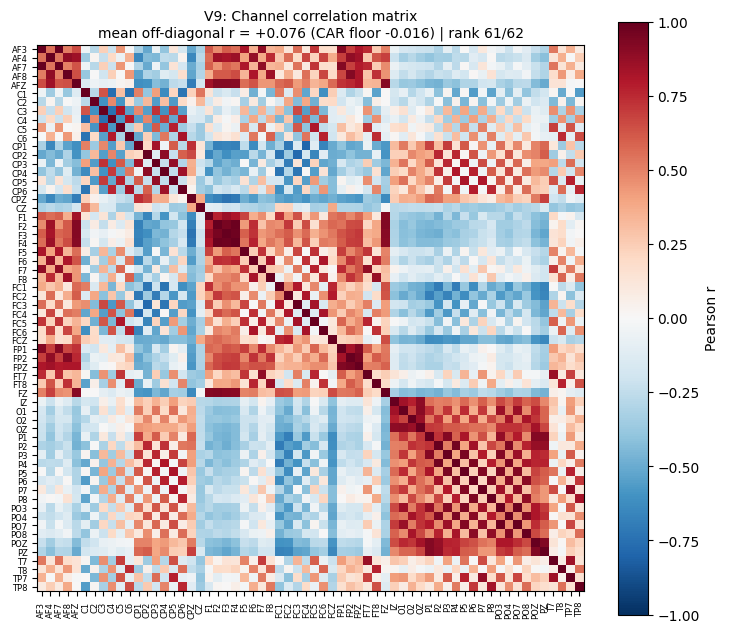

V5 - effective rank by dataset (median):
             n_channels  n_real_channels  effective_rank
dataset                                                 
bnci2014001        62.0             22.0            21.0
cho2017            62.0             62.0            61.0
dreyer2023         62.0             27.0            26.0
lee2019            62.0             48.0            47.0
physionet          62.0             62.0            61.0
weibo2014          62.0             58.0            57.0
Rank well below n_channels means those extra rows are linear combinations, not independent measurements.


,n_channels,n_real_channels,effective_rank
dataset,,,
bnci2014001,62.0,22.0,21.0
cho2017,62.0,62.0,61.0
dreyer2023,62.0,27.0,26.0
lee2019,62.0,48.0,47.0
physionet,62.0,62.0,61.0
weibo2014,62.0,58.0,57.0


In [37]:
fig, _ = viz.plot_class_balance(epochs_by_subject); plt.show()

any_ep = next(iter(epochs_by_subject.values()))
viz.plot_channel_variance_boxplot(any_ep); plt.show()
viz.plot_channel_correlation_heatmap(any_ep); plt.show()

rank_df = audits.audit_effective_rank(epochs_by_subject)
display(rank_df.groupby("dataset")[["n_channels", "n_real_channels", "effective_rank"]].median())

In [38]:
_ = abl.audit_dataset_identity_shortcut(epochs_by_subject, glob)

                               Probe Accuracy    Std  N_datasets MajorityRate
Dataset identity from log band-power   99.99% ±0.03%           6       29.42%
Near-ceiling accuracy here means the pooled task score above is an upper bound: the model can condition on dataset identity. Quote the per-dataset rows for generalisation claims.


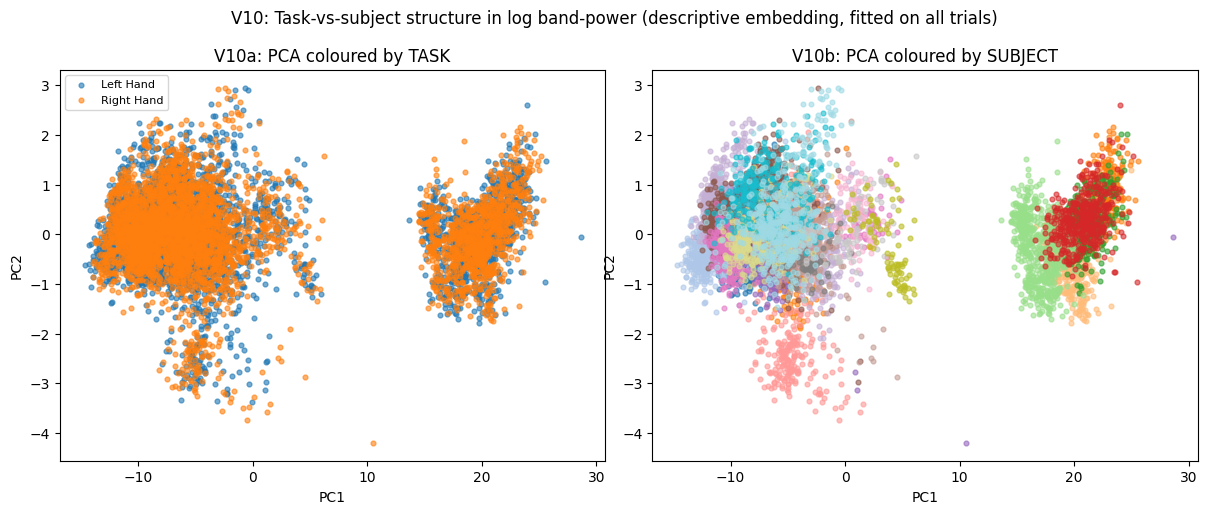

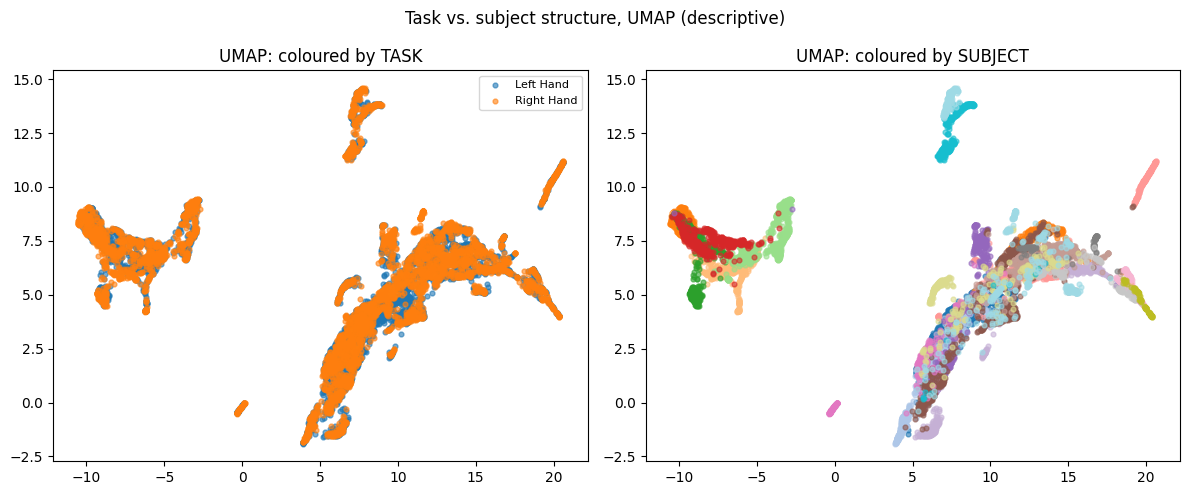

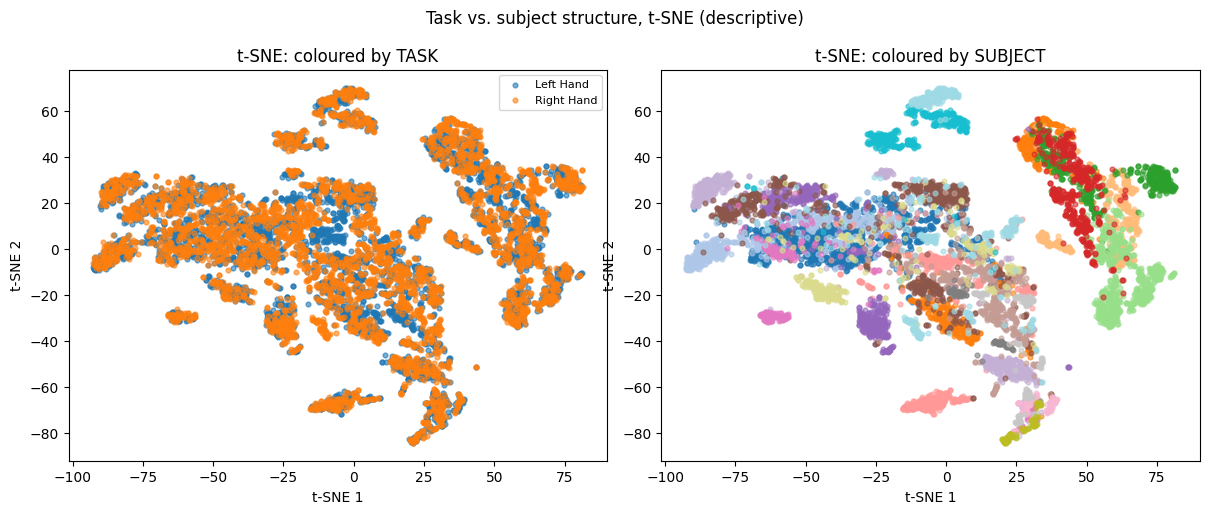


============ RAW FEATURE SEPARABILITY ============
                 Target                                        CV Strategy Accuracy    Std Chance (majority) Interpretable as generalisation?
                   Task   StratifiedGroupKFold (K=5, grouped by recording)   59.07% ±4.72%            47.24%                              yes
Subject (45 recordings) StratifiedKFold (K=5, TRIAL-level, within-subject)   86.60% ±0.92%             2.22%   NO -- identity probe by design
Features: 18 channels real in every recording, 8.0-30.0 Hz log band-power.
Disparity (Acc_S / Acc_T): 1.47x -- large values mean subject identity dominates task information in these raw features, which is the motivation for alignment/normalization, not a defect.



,Target,CV Strategy,Accuracy,Std,Chance (majority),Interpretable as generalisation?
0,Task,"StratifiedGroupKFold (K=5, grouped by recording)",59.07%,±4.72%,47.24%,yes
1,Subject (45 recordings),"StratifiedKFold (K=5, TRIAL-level, within-subj...",86.60%,±0.92%,2.22%,NO -- identity probe by design


In [39]:
fig, X, tasks, subjects = viz.plot_task_vs_subject_pca(epochs_by_subject, band=glob.BANDPASS); plt.show()
fig, *_ = viz.plot_task_vs_subject_umap(epochs_by_subject, band=glob.BANDPASS); plt.show()
fig, *_ = viz.plot_task_vs_subject_tsne(epochs_by_subject, band=glob.BANDPASS); plt.show()

results_df, (acc_t, acc_s) = ca.evaluate_raw_feature_separability(
    epochs_by_subject, band=glob.BANDPASS)
results_df

In [40]:
# --- Section 17: filter-support / recording-boundary audit ---------------
# Every dataset's primary epoch window, expanded by the FIR half-support on
# each side, must fit inside that dataset's own real signal support:
#     [-pre_cue_clean_sec, trial_length_sec]
# The inter-trial interval is NOT the right bound here, because the data is
# filtered continuously before epoching; see audit_filter_support_bounds's
# docstring for the full reasoning.
filter_half_support = pkg.fir_half_length_sec(
    glob.TARGET_SFREQ, glob.BANDPASS[0], glob.BANDPASS[1],
    glob.FIR_TRANS_BANDWIDTH)
print(f"Filter half-support: {filter_half_support:.3f} s "
      f"(at {glob.TARGET_SFREQ:.0f} Hz, {glob.BANDPASS[0]:g}-{glob.BANDPASS[1]:g} Hz, "
      f"{glob.FIR_TRANS_BANDWIDTH:g} Hz transition)\n")

support_df = pkg.audit_filter_support_bounds(registry, glob, filter_half_support)
pkg.save_table(support_df, "audit_filter_support_bounds")
pkg.save_json({"filter_half_support_sec": float(filter_half_support),
                "target_sfreq": float(glob.TARGET_SFREQ),
                "bandpass": list(glob.BANDPASS),
                "trans_bandwidth": float(glob.FIR_TRANS_BANDWIDTH)},
               "filter_support_metadata")

Filter half-support: 0.828 s (at 128 Hz, 8-30 Hz, 2 Hz transition)

    Dataset       Epoch Effective support Available support Safe?                                                   Note
  physionet 1–2.99219 s     0.172–3.820 s    -2.000–4.000 s     ✓                                                       
    cho2017 1–2.99219 s     0.172–3.820 s    -2.000–3.000 s     ✗ right: only 3.000s available, effective reaches 3.820s
    lee2019 1–2.99219 s     0.172–3.820 s    -3.000–4.000 s     ✓                                                       
bnci2014001 1–2.99219 s     0.172–3.820 s    -2.000–4.000 s     ✓                                                       
  weibo2014 1–2.99219 s     0.172–3.820 s    -2.000–4.000 s     ✓                                                       
 dreyer2023 1–2.99219 s     0.172–3.820 s    -0.800–5.000 s     ✓                                                       
[output] table  -> /kaggle/working/output/tables/audit_filter_support_bounds.csv
[out

PosixPath('/kaggle/working/output/json/filter_support_metadata.json')

## Section 18 — Cohort-scale ERD/ERS, with the Hilbert edge effect actually fixed

### Why reflection padding was the wrong fix

`scipy.signal.hilbert` computes the analytic signal through the DFT, so it treats an epoch as one period of a periodic signal: the step between the last and first sample injects a broadband transient that ruins roughly one cycle of the lowest analysed frequency at each end. At 8 Hz that is ~125 ms — 12% of a 2 s epoch, sitting exactly where ERD onset and offset are read off.

The intuitive remedy is to reflection-pad the epoch before transforming. **Measured on simulated 9–13 Hz oscillations with a known ERD-shaped envelope, that is worse than doing nothing:**

| edge handling | mean abs. envelope error in outer 125 ms |
|---|---|
| no padding | 0.334 |
| reflection padding | **0.438** |
| real-data margin ±1 s | **0.003** |

Even-symmetric reflection makes the signal continuous in *value* but flips the sign of its *slope* at the boundary — it replaces a step discontinuity with a cusp, which for a narrowband oscillation is the larger artefact.

So the fix is not to invent samples. `build_baseline_ablation_epochs` epochs **wider than it displays**, takes the analytic signal over the longer real segment, and crops the margin away. The margin is whatever each dataset can spare: Cho2017's 3.0 s post-cue trial allows the full 1 s, Dreyer2023's auditory warning 1 s before the cue allows much less, and the reduction is printed per dataset rather than silently applied.

`BASELINE_ABLATION_EPOCH_WINDOW` was shortened to (−0.5, 2.0) precisely so a full margin still fits inside Cho2017, the binding constraint.

In [41]:
erd_epochs_by_subject = ca.build_erd_cohort(
    registry, channel_mapping_df, common_channels, montage, glob_safe,
    n_subjects_per_dataset, car_scope_channels=car_scope, max_subjects_per_dataset=5)
print(f"\nERD/ERS epochs for {len(erd_epochs_by_subject)} recordings.")


[ERD cohort] Dispatching 27 subject(s) with n_jobs=2.


[ERD] cohort:   0%|          | 0/27 [00:00<?, ?subject/s]

Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Starting caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012


Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

Finished caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012 to disk.
Starting caching 'Lee2019-MI' sub-2 suffix-eeg desc-b444012


...

Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
[dreyer2023] envelope margin reduced to 0.30s (pre-cue budget 0.80s, post-cue trial 5.00s). Edge handling is proportionally weaker.


9it [00:00, 8088.44it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
[dreyer2023] envelope margin reduced to 0.30s (pre-cue budget 0.80s, post-cue trial 5.00s). Edge handling is proportionally weaker.


9it [00:00, 4772.28it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 234495  =      0.000 ...   457.998 secs...

ERD/ERS epochs for 27 recordings.


physionet/S001: epoched [-1.50, 3.00]s, displaying (-0.5, 2.0)


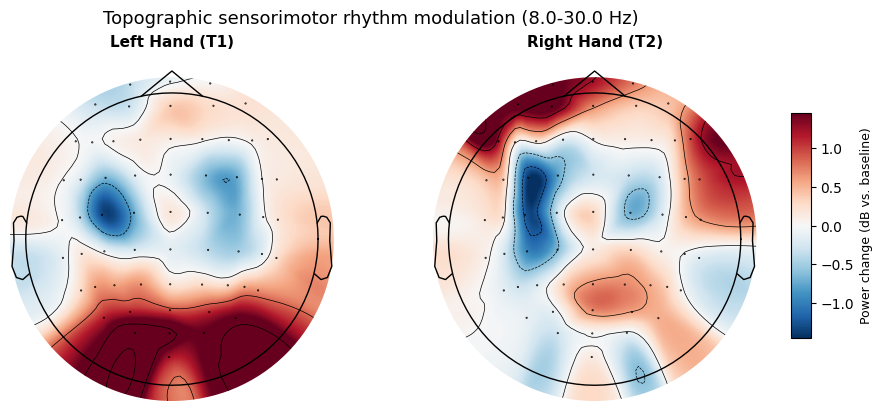

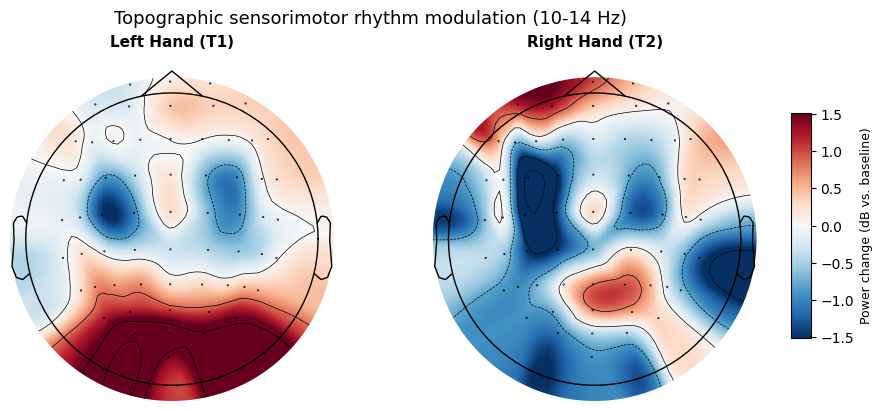

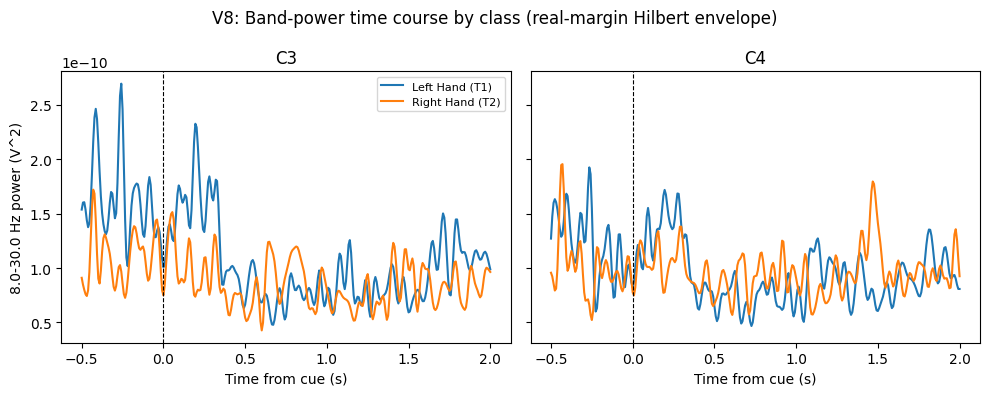

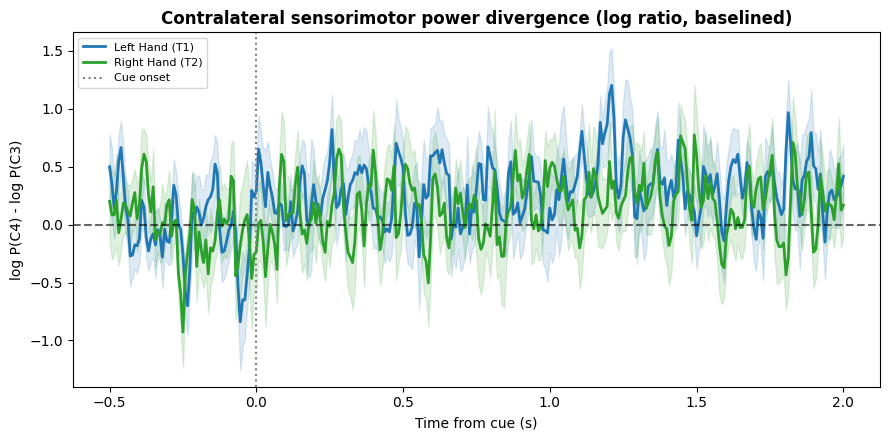

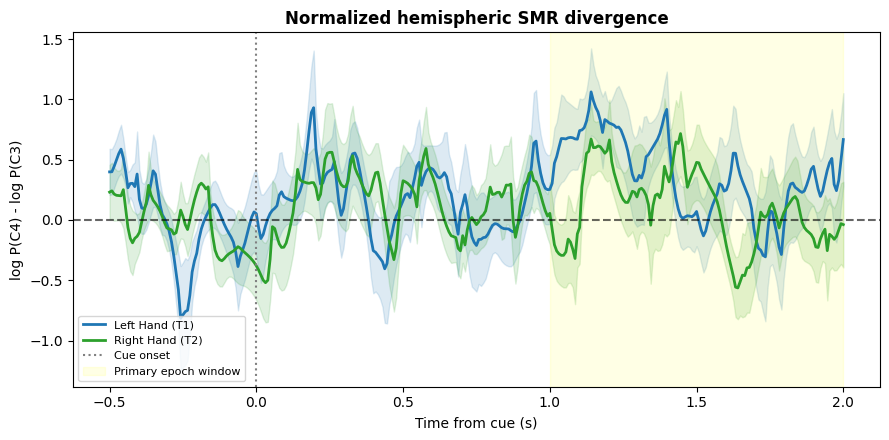

In [42]:
demo_key = next(iter(erd_epochs_by_subject))
demo_erd = erd_epochs_by_subject[demo_key]
display_window = ca.get_display_window(demo_erd)
print(f"{demo_key}: epoched [{demo_erd.times[0]:.2f}, {demo_erd.times[-1]:.2f}]s, "
      f"displaying {display_window}")

viz.plot_motor_imagery_topomaps(demo_erd, band=glob.BANDPASS); plt.show()
viz.plot_mu_topomaps_decibels(demo_erd); plt.show()
viz.plot_bandpower_timecourse(demo_erd, band=glob.BANDPASS,
                              display_window=display_window); plt.show()
viz.plot_lateralization_index(demo_erd, band=glob.BANDPASS,
                              display_window=display_window); plt.show()
viz.plot_normalized_lateralization(demo_erd, display_window=display_window,
                                   primary_window=(1.0, 2.0)); plt.show()

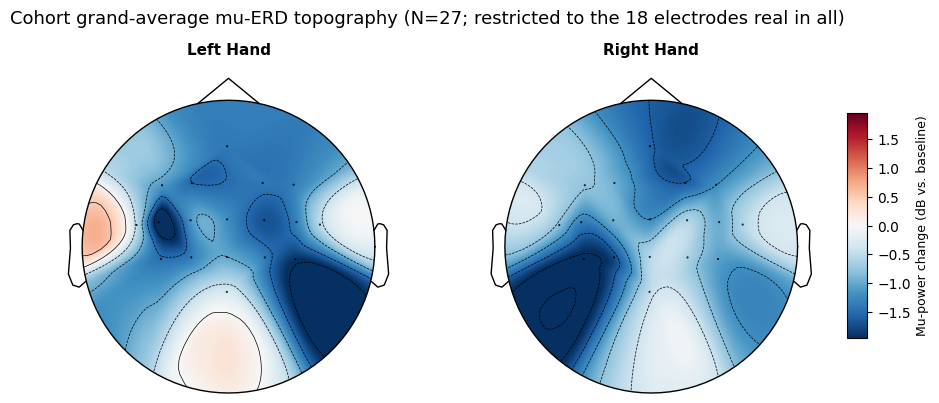

No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied


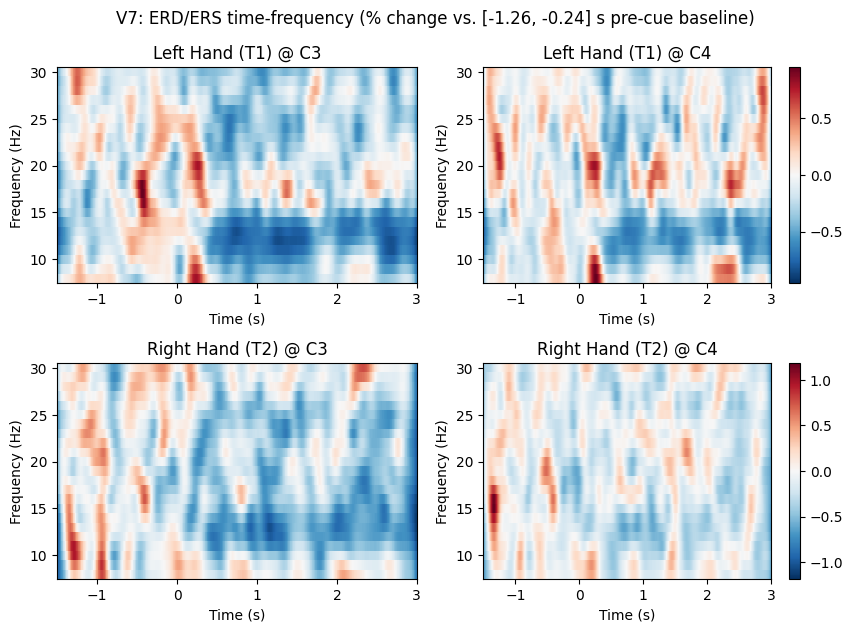

In [43]:
# Grand average over recordings, restricted to channels real in ALL of them.
# Averaging a masked zero into a grand mean pulls that electrode's ERD toward
# 0 dB in proportion to how many datasets lack it, which reads as a weak but
# genuine effect rather than as missing data.
viz.compute_grand_average_topomap(erd_epochs_by_subject); plt.show()

try:
    viz.plot_erd_ers_tfr(demo_erd, picks=("C3", "C4")); plt.show()
except Exception as exc:
    print("TFR skipped:", exc)

In [44]:
glob_safe = dataclasses.replace(glob, COHORT_N_JOBS=1)

In [45]:
# --- Section 18: analysis-band ablation ----------------------------------
# 8-30 Hz stays primary. The wider bands are tested only to confirm a wider
# passband does not buy real decoding accuracy.
band_df = pkg.ablation_frequency_band(
    registry, channel_mapping_df, montage, glob_safe,
    n_subjects_per_dataset, common_channels, car_scope,
    classifier_name="CSP+LDA")
print(band_df.to_string(index=False))
pkg.save_table(band_df, "ablation_frequency_band")

# Same ablation with the Riemannian classifier, for a classifier-agnostic check.
band_df_riem = pkg.ablation_frequency_band(
    registry, channel_mapping_df, montage, glob,
    n_subjects_per_dataset, common_channels, car_scope,
    classifier_name="Riemannian_TS+LR")
print(band_df_riem.to_string(index=False))
pkg.save_table(band_df_riem, "ablation_frequency_band_riemannian")

Frequency-band ablation:   0%|          | 0/3 [00:00<?, ?band/s]

[cohort build] Dispatching 45 subject(s) across 6 dataset(s) with n_jobs=1 (variant='primary').


[primary] cohort:   0%|          | 0/45 [00:00<?, ?subject/s]

Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Starting caching 'Lee2019-MI' sub-1 suffix-eeg des

Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

...

9it [00:00, 3330.87it/s]
9it [00:00, 3827.70it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...


9it [00:00, 3779.79it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
            Setup Accuracy    Std BalancedAcc   AUC MajorityRate  N_trials  N_subjects  K Band_Hz Band_width_Hz
8-30 Hz (primary)   59.75% ±3.05%      59.75% 0.638       50.06%      8158          45  5    8-30            22
          8-32 Hz   59.48% ±3.22%      59.48% 0.639       50.06%      8158          45  5   

PosixPath('/kaggle/working/output/tables/ablation_frequency_band_riemannian.csv')

## Section 19 — Classical BCI baselines

`FBCSP` is now actually FBCSP. The previous `SimpleFBCSP` was missing the defining stage — mutual-information feature selection over the filter bank (Ang et al. 2008) — so it was just a wider CSP; it built its CSP objects in `__init__` and mutated them in `fit`, so a deepcopy-"clone" shared fitted spatial filters with its parent; it was not a scikit-learn estimator, which is why the previous notebook monkey-patched `get_params`/`set_params`/`score`/`__sklearn_clone__` onto the class at runtime; and its 28–32 Hz band sat outside the 8–30 Hz analysis passband, contributing near-zero-variance features for the selector to chase.

Now: zero-phase Chebyshev Type II sub-bands tiling the actual passband, CSP per band built inside `fit`, MIBIF selection with the paired-feature rule, shrinkage LDA. No patching needed.

In [46]:
X_all, y_all, groups_all, ds_all = abl.flatten_epochs_dict(epochs_by_subject)
print(f"Pooled tensor: {X_all.shape} | {len(set(groups_all))} recordings | "
      f"majority class {abl.empirical_chance(y_all):.2%}")

baseline_rows = []
for name, clf in build_all_baselines(sfreq=glob.TARGET_SFREQ).items():
    acc, std, bacc, auc, k = abl.cv_accuracy(
        X_all, y_all, groups_all, clf, k=glob.CV_FOLDS, return_detail=True)
    baseline_rows.append(dict(Model=name, Accuracy=f"{acc:.2%}", Std=f"±{std:.2%}",
                              BalancedAcc=f"{bacc:.2%}", AUC=f"{auc:.3f}",
                              MajorityRate=f"{abl.empirical_chance(y_all):.2%}", K=k))
baselines_df = pd.DataFrame(baseline_rows)
baselines_df


Pooled tensor: (8158, 62, 256) | 45 recordings | majority class 50.06%
Computing rank from data with rank=None
    Using tolerance 0.0041 (2.2e-16 eps * 62 dim * 3e+11  max singular value)
    Estimated rank (data): 61
    data: rank 61 computed from 62 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 62 -> 61
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 0.0043 (2.2e-16 eps * 62 dim * 3.1e+11  max singular value)
    Estimated rank (data): 61
    data: rank 61 computed from 62 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 62 -> 61
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (

,Model,Accuracy,Std,BalancedAcc,AUC,MajorityRate,K
0,CSP+LDA,58.68%,±4.32%,58.68%,0.617,50.06%,5
1,Riemannian_TS+LR,59.75%,±3.05%,59.75%,0.638,50.06%,5
2,FBCSP (MIBIF),56.28%,±2.31%,56.29%,0.592,50.06%,5


In [47]:
# Per-dataset breakdown -- the honest comparison. A pooled score far above
# every per-dataset score means the pooled model is exploiting dataset identity.
per_dataset_df = abl.per_dataset_breakdown(
    epochs_by_subject, build_all_baselines(glob.TARGET_SFREQ)["CSP+LDA"], k=glob.CV_FOLDS)
per_dataset_df

Computing rank from data with rank=None
    Using tolerance 5.6e-05 (2.2e-16 eps * 62 dim * 4.1e+09  max singular value)
    Estimated rank (data): 21
    data: rank 21 computed from 62 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 62 -> 21
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 7.1e-05 (2.2e-16 eps * 62 dim * 5.1e+09  max singular value)
    Estimated rank (data): 21
    data: rank 21 computed from 62 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 62 -> 21
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tole

,Setup,Accuracy,Std,BalancedAcc,AUC,MajorityRate,N_trials,N_subjects,K
0,bnci2014001,65.28%,±12.24%,65.28%,0.726,50.00%,1728,6,5
1,cho2017,60.70%,±5.72%,60.70%,0.643,50.00%,2080,10,5
2,dreyer2023,54.96%,±1.64%,54.96%,0.566,50.00%,2400,10,5
3,lee2019,62.75%,±6.25%,62.75%,0.696,50.00%,400,2,2
4,physionet,51.56%,±3.56%,51.27%,0.522,51.11%,450,10,5
5,weibo2014,65.50%,±10.01%,65.50%,0.727,50.00%,1100,7,5


In [48]:
# What MIBIF actually selected, on the full pooled set -- a look at which
# sub-bands carry the discriminative information.
fb = FBCSP(sfreq=glob.TARGET_SFREQ).fit(X_all, y_all)
sel = pd.DataFrame({
    "feature": fb.selected_idx_,
    "band": [f"{fb.bands_[i // fb.n_components][0]:.0f}-"
             f"{fb.bands_[i // fb.n_components][1]:.0f} Hz" for i in fb.selected_idx_],
    "csp_component": [i % fb.n_components for i in fb.selected_idx_],
    "mutual_info": [f"{fb.mutual_info_[i]:.4f}" for i in fb.selected_idx_],
})
print(f"Filter bank: {fb.bands_}")
sel

Computing rank from data with rank=None
    Using tolerance 0.0029 (2.2e-16 eps * 62 dim * 2.1e+11  max singular value)
    Estimated rank (data): 61
    data: rank 61 computed from 62 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 62 -> 61
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 0.0016 (2.2e-16 eps * 62 dim * 1.1e+11  max singular value)
    Estimated rank (data): 61
    data: rank 61 computed from 62 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 62 -> 61
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolera

,feature,band,csp_component,mutual_info
0,5,12-16 Hz,1,0.0127
1,6,12-16 Hz,2,0.0095
2,13,20-24 Hz,1,0.0072
3,14,20-24 Hz,2,0.0119
4,16,24-28 Hz,0,0.0049
5,17,24-28 Hz,1,0.0114
6,18,24-28 Hz,2,0.0114
7,19,24-28 Hz,3,0.0127


In [49]:
# --- Section 19: line-noise diagnostics ----------------------------------
# 50/60 Hz is OUTSIDE the primary 8-30 Hz band-pass, so a notch is not
# required for the primary result. But the ICA ablation fits on a broadband
# (1-100 Hz) copy where line noise IS present at full amplitude, and ICLabel
# can mislabel a line-noise component as brain or muscle. This audit
# measures how big the problem actually is per dataset.
line_df = pkg.audit_line_noise(registry, subjects_per_dataset=2)
print(line_df.to_string(index=False))
pkg.save_table(line_df, "audit_line_noise")

# A/B the ICA ablation with and without a notch at the dominant line
# frequency. Both rows use variant='ica' -- the same broadband + ICLabel
# pipeline -- so the only change is whether the raw is notched first.
line_freq = 50.0   # or: float(line_df["likely_line_freq"].mode()[0])
ica_notch_df = pkg.ablation_ica_with_without_notch(
    registry, channel_mapping_df, common_channels, montage, glob_safe,
    n_subjects_per_dataset, car_scope,
    classifier_name="CSP+LDA", line_freq=line_freq)
print(ica_notch_df.to_string(index=False))
pkg.save_table(ica_notch_df, "ablation_ica_with_without_notch")

Line-noise audit:   0%|          | 0/6 [00:00<?, ?dataset/s]

Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Starting caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012


Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

Finished caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012 to disk.
Trial data de-meaned and concatenated with a buffer to create cont data

9it [00:00, 2628.19it/s]


Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
    dataset  native_sfreq  band_8_30_power   power_50Hz  ratio_50Hz_over_8_30   power_60Hz  ratio_60Hz_over_8_30  likely_line_freq
  physionet         160.0     1.625490e-11 2.316524e-12              0.142512 2.105303e-12              0.129518                50
    cho2017         512.0     3.920427e-09 2.905483e-10              0.074111 7.042755e-09              1.796425                60
    lee2019        1000.0     2.258392e-12 1.079254e-12              0.477886 5.771077e-12              2.555392                60
bnci2014001         250.0     1.149016e-12 2.423543e-14              0.021092 5.533719e-14              0.048160                60
  w

...


9it [00:00, 2969.07it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Fitting ICA to data using 27 channels (please be patient, this may take a while)
Selecting by number: 26 components
Fitting ICA took 63.0s.
[ICA ablation] fit on broadband copy (27 real ch); excluded 0 component(s): []



9it [00:00, 2418.55it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Fitting ICA to data using 27 channels (please be patient, this may take a while)
Selecting by number: 26 components
Fitting ICA took 56.0s.
[ICA ablation] fit on broadband copy (27 real ch); excluded 2 component(s): ['heart beat', 'eye blink']
Computing rank from data with rank=None
    Using tolerance 0.0042 (2.2e-16 eps * 62 dim * 3e+11  max singular value)
    Estimated rank (data): 62
    data: rank 62 computed from 62 data channels with 0 projectors
Reducing data rank from 62 -> 62
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using toleranc

PosixPath('/kaggle/working/output/tables/ablation_ica_with_without_notch.csv')

## Section 20 — Augmentation sanity check

Two fixes: the `jitter_mode` type hint listed `"crop_resample"` while the implementation only accepted `"crop_and_resample"`, so the documented value raised; and `temporal_jitter` drew one shift and applied it to the whole batch, making it a batch-level perturbation rather than per-sample augmentation.

In [50]:
import torch
augmenter = EEGAugmentationTransform(sfreq=glob.TARGET_SFREQ, max_jitter_ms=100.0,
                                      jitter_mode="crop_and_resample")
batch = torch.randn(16, len(common_channels), glob.EXPECTED_TIME_SAMPLES)
out = augmenter(batch)
print("Augmented batch:", tuple(out.shape))

# Per-trial independence: identical input rows must come out different.
same = batch[:1].repeat(8, 1, 1)
jit = augmenter.temporal_jitter(same)
n_distinct = len({jit[i].numpy().tobytes() for i in range(8)})
print(f"Distinct outputs from 8 identical inputs: {n_distinct}/8 "
      f"({'per-trial shifts confirmed' if n_distinct > 1 else 'STILL BATCH-LEVEL'})")

Augmented batch: (16, 62, 256)
Distinct outputs from 8 identical inputs: 7/8 (per-trial shifts confirmed)


In [51]:
# --- Section 20: artifact-preservation metrics ---------------------------
# Accuracy alone cannot say whether a cleaning method preserves
# neurophysiology. These metrics DO: rejection rate, variance removed, and
# how much mu power, beta power and mu-ERD magnitude were kept relative to
# the primary. The ideal result is small rejection, small power/ERD change,
# and raw / topography correlation above ~0.9.
# Sample subjects per dataset is small on purpose -- this is expensive (it
# builds every variant for every subject). Raise via `preserve_spec` below
# when you have compute budget.
preserve_spec = {cfg.name: 2 for cfg in registry.enabled()}
preserve_df = pkg.audit_artifact_preservation(
    registry, channel_mapping_df, common_channels, montage, glob_safe,
    car_scope, subjects_per_dataset=preserve_spec)
print(preserve_df.to_string(index=False))
pkg.save_table(preserve_df, "audit_artifact_preservation")

Artifact preservation:   0%|          | 0/6 [00:00<?, ?dataset/s]

Fitting ICA to data using 62 channels (please be patient, this may take a while)
Selecting by number: 61 components
Fitting ICA took 32.2s.
[ICA ablation] fit on broadband copy (62 real ch); excluded 5 component(s): ['eye blink', 'heart beat', 'muscle artifact', 'muscle artifact', 'muscle artifact']
[AutoReject ablation] Rejected 0/45 trials (0.0%).
[Channel-rejection ablation] Interpolating 4 bad channel(s): ['IZ', 'O1', 'O2', 'OZ']
Fitting ICA to data using 62 channels (please be patient, this may take a while)
Selecting by number: 61 components
Fitting ICA took 34.7s.
[ICA ablation] fit on broadband copy (62 real ch); excluded 6 component(s): ['eye blink', 'eye blink', 'muscle artifact', 'muscle artifact', 'eye blink', 'muscle artifact']
[AutoReject ablation] Rejected 0/45 trials (0.0%).
[Channel-rejection ablation] Interpolating 1 bad channel(s): ['O2']


Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present


Fitting ICA to data using 62 channels (please be patient, this may take a while)
Selecting by number: 61 components
Fitting ICA took 154.0s.
[ICA ablation] fit on broadband copy (62 real ch); excluded 4 component(s): ['eye blink', 'eye blink', 'eye blink', 'muscle artifact']


Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present


...

Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Dropped 46 epochs: 15, 21, 27, 33, 39, 52, 84, 97, 101, 107, 109, 110, 113, 114, 115, 116, 118, 119, 129, 130, 141, 142, 155, 162, 167, 176, 181, 182, 184, 185, 196, 200, 201, 202, 203, 205, 208, 209, 214, 218, 219, 220, 224, 227, 229, 238
[AutoReject ablation] Rejected 46/240 trials (19.2%).



9it [00:00, 2865.18it/s]

Reading 0 ... 230911  =      0.000 ...   450.998 secs...


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
[Channel-rejection ablation] Interpolating 7 bad channel(s): ['C1', 'C4', 'CP2', 'F4', 'FC1', 'FC4', 'FCZ']

========== ARTIFACT-PRESERVATION METRICS ==========
    Dataset  Subject        Variant  N_trials_primary  N_trials_variant Reject_pct Var_removed_pct Mu_power_change_pct Beta_power_change_pct ERD_mu_change_dB Raw_corr Topo_corr
  physionet        1            ica                45                45       0.0%           -6.4%               +5.5%                 +4.7%             +nan    0.669     0.694
  physionet        1     autoreject                45                45       0.0%           +0.0%               +0.0%                 +0.0%             +nan    1.000     1.000
  physionet        1 ch

PosixPath('/kaggle/working/output/tables/audit_artifact_preservation.csv')

## Section 21 — Validation suite

Terminology corrected, and two of these tests now check something.

**T1 `audit_car_memoryless`** — CAR is a *memoryless* spatial operator, not a causal one. The old version recomputed `data - data.mean(0)` inline and asserted the result, making it a tautology about its own arithmetic; it now calls the real pipeline function.

**T2 `audit_filter_leakage_bound`** — the band-pass runs with `phase="zero"`, which is **non-causal by construction**: a symmetric impulse response means output at t depends on input both before and after t. The honest question is how far energy travels. The old test injected a perturbation at `tmax + 1.5 s` and asserted zero leakage — but the FIR half-support at 160 Hz with a 2 Hz transition band is ≈1.65 s, so the perturbation was *inside* the filter's reach and the test was checking numerical luck. The guard is now computed from the actual filter length.

**T3 `audit_epoch_isolation`** — new, and the one that matters for the data: whether adjacent trials are far enough apart that the filter cannot carry one trial's energy into the next trial's epoch.

**T5** — the boundary check indexed the raw array with `ev[0]` without subtracting `raw.first_samp`, so every comparison was shifted for any recording with a non-zero first sample.

**L4** — `audit_feature_leakage` was **vacuous**: it perturbed a detached `.copy()` and then refit on the unchanged train list, so it would have passed even if the normalizer had been handed test data directly. It now perturbs in place.

In [52]:
results = {}
subject_ids = list(epochs_by_subject.keys())
split = max(1, len(subject_ids) - 3)

demo_pipe = pipelines[next(iter(pipelines))]
demo_raws = demo_pipe.cfg.loader_fn(1)
demo_raw = mne.concatenate_raws([r.copy() for r in demo_raws]) if len(demo_raws) > 1 else demo_raws[0]

# --- leakage ---
results["L1_subject_split_disjoint"] = audits.audit_subject_split_integrity(
    subject_ids[:split], subject_ids[split:])
results["L2_channel_set_determinism"] = audits.audit_channel_set_determinism(
    registry, mode=glob.HARMONIZATION_MODE, anchor_datasets=list(glob.ANCHOR_DATASETS))
results["L3_no_duplicate_trials"] = audits.audit_duplicate_trials(epochs_by_subject)
results["L5_normalizer_multi_split"] = audits.audit_normalizer_multi_split(epochs_by_subject)

# --- temporal properties ---
results["T1_car_memoryless"] = audits.audit_car_memoryless(
    demo_raw, common_channels=common_channels, montage=montage,
    channel_mapping_df=channel_mapping_df, mode=glob.HARMONIZATION_MODE,
    car_scope_channels=car_scope)
results["T4_filter_before_resample"] = audits.audit_filter_resample_order(
    demo_raw, l_freq=glob.BANDPASS[0], h_freq=glob.BANDPASS[1],
    target_sfreq=glob.TARGET_SFREQ, trans_bandwidth=glob.FIR_TRANS_BANDWIDTH)

raw_car_sample = set_common_average_reference(
    preprocess_raw(demo_raw.copy(), channel_mapping_df, common_channels, montage,
                   l_freq=glob.BANDPASS[0], h_freq=glob.BANDPASS[1],
                   target_sfreq=glob.TARGET_SFREQ, mode=glob.HARMONIZATION_MODE,
                   trans_bandwidth=glob.FIR_TRANS_BANDWIDTH), car_scope)
events_sample, _ = mne.events_from_annotations(
    raw_car_sample, event_id=demo_pipe.cfg.event_id, verbose=False)
results["T5_epoch_boundary_containment"] = audits.audit_epoch_boundary_containment(
    raw_car_sample, events_sample, demo_pipe.cfg.event_id, glob.PRIMARY_EPOCH_WINDOW,
    cue_offset_sec=demo_pipe.cfg.cue_offset_sec)

# --- invariants ---
results["V1_cohort_tensor_consistency"] = audits.audit_cohort_tensor_consistency(
    epochs_by_subject, expected_sfreq=glob.TARGET_SFREQ)
results["V2_cohort_finite_values"] = audits.audit_cohort_finite_values(epochs_by_subject)
results["V3_pipeline_determinism"] = audits.audit_pipeline_determinism(demo_pipe, 1)
results["V4_trial_count_bounds"] = audits.audit_trial_count_bounds(epochs_by_subject)

print("\n==================== VALIDATION SUITE ====================")
for name, status in results.items():
    print(f"[*] {name:<34}: {'PASSED' if status else 'FAILED'}")
print("=" * 58)

PASS: L1 - train (42) and test (3) subject sets are disjoint.
PASS: L2 - channel set is deterministic and name-only (62 channels, mode='reference_masked', 6 dataset(s) enabled).
PASS: L3 - no duplicate trials across 45 recordings (8158 trials hashed).
  split 0: train=42 subj, test=['dreyer2023/S005', 'bnci2014001/S004', 'bnci2014001/S005'], delta=0.00e+00 -> PASS
  split 1: train=42 subj, test=['physionet/S003', 'physionet/S001', 'bnci2014001/S005'], delta=0.00e+00 -> PASS
  split 2: train=42 subj, test=['physionet/S004', 'cho2017/S008', 'weibo2014/S004'], delta=0.00e+00 -> PASS
  split 3: train=42 subj, test=['cho2017/S008', 'dreyer2023/S010', 'physionet/S008'], delta=0.00e+00 -> PASS
  split 4: train=42 subj, test=['weibo2014/S002', 'cho2017/S006', 'physionet/S004'], delta=0.00e+00 -> PASS
PASS: L5 - normalizer train/test independence across 5 random splits.
PASS: T1 - the average reference is memoryless (only sample 24000 changed, on channel 'AF3').
PASS: T4 - matches filter-then-r


==================== VALIDATION SUITE ====================
[*] L1_subject_split_disjoint         : PASSED
[*] L2_channel_set_determinism        : PASSED
[*] L3_no_duplicate_trials            : PASSED
[*] L5_normalizer_multi_split         : PASSED
[*] T1_car_memoryless                 : PASSED
[*] T4_filter_before_resample         : PASSED
[*] T5_epoch_boundary_containment     : PASSED
[*] V1_cohort_tensor_consistency      : PASSED
[*] V2_cohort_finite_values           : PASSED
[*] V3_pipeline_determinism           : PASSED
[*] V4_trial_count_bounds             : PASSED


In [53]:
# --- Section 21: consolidated amplitude / SNR QC table -------------------
# One row per (dataset, subject), every amplitude- and SNR-side statistic
# alongside any cleaning-side counts we have (joined from the previous
# block when available).
qc_spec = {cfg.name: 3 for cfg in registry.enabled()}
qc_df = pkg.build_qc_table(
    registry, channel_mapping_df, common_channels, montage, glob_safe,
    car_scope, subjects_per_dataset=qc_spec,
    cleaning_stats=preserve_df)
print(qc_df.to_string(index=False))
pkg.save_table(qc_df, "amplitude_snr_qc")

QC table:   0%|          | 0/6 [00:00<?, ?dataset/s]

Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Starting caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012


Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

Finished caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012 to disk.
Starting caching 'Lee2019-MI' sub-2 suffix-eeg desc-b444012


Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-2/ses-1/eeg/sub-2_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-2/ses-1/eeg/sub-2_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-2/ses-1/eeg/sub-2_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-2/ses-1/eeg/sub-2_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

...

Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...



9it [00:00, 4339.93it/s]

Reading 0 ... 230911  =      0.000 ...   450.998 secs...


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...

========== AMPLITUDE / SNR QC ==========
    dataset  subject              key  n_trials_used  n_rejected  reject_pct  flat_channels  extreme_trials  nan_inf_count  p2p_median_uV  rms_median_uV  spectral_outlier_channels  n_real_channels  n_masked_channels  n_channels_total reject_pct_ica reject_pct_autoreject reject_pct_channel_reject
  physionet        1   physionet/S001             45           0         0.0              0               0              0         66.165         11.465                          3               62                  0                62           0.0%                  0.0%                      0.0%
  physionet        2   physionet/S002             45           0         0.0   

PosixPath('/kaggle/working/output/tables/amplitude_snr_qc.csv')

In [54]:
# T2/T3 -- the filter's actual reach, per dataset. These return measurements,
# not just booleans: read fir_half_support_sec against median_iti_sec.
reach_rows = []
for name, pipe in pipelines.items():
    try:
        raws = pipe.cfg.loader_fn(1)
        raw = mne.concatenate_raws([r.copy() for r in raws]) if len(raws) > 1 else raws[0]
        b = audits.audit_filter_leakage_bound(
            raw, pipe.cfg.event_id, glob.PRIMARY_EPOCH_WINDOW,
            cue_offset_sec=pipe.cfg.cue_offset_sec,
            l_freq=glob.BANDPASS[0], h_freq=glob.BANDPASS[1],
            trans_bandwidth=glob.FIR_TRANS_BANDWIDTH)
        i = audits.audit_epoch_isolation(
            raw, pipe.cfg.event_id, glob.PRIMARY_EPOCH_WINDOW,
            cue_offset_sec=pipe.cfg.cue_offset_sec,
            l_freq=glob.BANDPASS[0], h_freq=glob.BANDPASS[1],
            trans_bandwidth=glob.FIR_TRANS_BANDWIDTH)
        reach_rows.append(dict(dataset=name, native_sfreq=pipe.cfg.native_sfreq,
                               fir_half_support_s=round(b["fir_half_support_sec"], 3),
                               guard_used_s=round(b["guard_sec"], 3),
                               leakage_ok=b["passed"],
                               median_iti_s=round(i["median_iti_sec"], 2),
                               epoch_support_s=round(i["effective_support_sec"], 2),
                               trials_isolated=i["passed"]))
    except Exception as exc:
        print(f"{name}: {exc}")
pd.DataFrame(reach_rows)

T2: zero-phase FIR half-support = 0.825s at 160 Hz (8.0-30.0 Hz, 2.0 Hz transition). The filter is NON-CAUSAL by design; this bounds its reach.
PASS: T2 - a perturbation 1.131s past the epoch end leaves it untouched (max delta 3.55e-13 V).
PASS: T3 - effective epoch support 3.64s fits inside the 8.30s median inter-trial interval.
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
T2: zero-phase FIR half-support = 0.824s at 512 Hz (8.0-30.0 Hz, 2.0 Hz transition). The filter is NON-CAUSAL by design; this bounds its reach.
PASS: T2 - a perturbation 1.130s past the epoch end leaves it untouched (max delta 1.62e-13 V).
PASS: T3 - effective epoch support 3.64s fits inside the 7.00s median inter-trial interval.
Starting caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012


Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/README'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/participants.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_coordsystem.json'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_space-CapTrak_electrodes.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Writing '/tmp/mne_data/MNE-BIDS-lee2019-mi/sub-1/ses-1/eeg/sub-1_ses-1_task-imagery_run-1_recording-train_desc-b444012360b3bf010c9f627f9ca75a34_events.tsv'...
Writing '/tmp/mne_data/MNE-BIDS-lee2019

Finished caching 'Lee2019-MI' sub-1 suffix-eeg desc-b444012 to disk.
T2: zero-phase FIR half-support = 0.825s at 1000 Hz (8.0-30.0 Hz, 2.0 Hz transition). The filter is NON-CAUSAL by design; this bounds its reach.
PASS: T2 - a perturbation 1.131s past the epoch end leaves it untouched (max delta 1.27e-13 V).
PASS: T3 - effective epoch support 3.64s fits inside the 11.05s median inter-trial interval.
T2: zero-phase FIR half-support = 0.824s at 250 Hz (8.0-30.0 Hz, 2.0 Hz transition). The filter is NON-CAUSAL by design; this bounds its reach.
PASS: T2 - a perturbation 1.130s past the epoch end leaves it untouched (max delta 1.93e-13 V).
PASS: T3 - effective epoch support 3.64s fits inside the 15.55s median inter-trial interval.
Trial data de-meaned and concatenated with a buffer to create cont data
T2: zero-phase FIR half-support = 0.825s at 200 Hz (8.0-30.0 Hz, 2.0 Hz transition). The filter is NON-CAUSAL by design; this bounds its reach.
PASS: T2 - a perturbation 1.131s past the epoch 

Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...


T2: zero-phase FIR half-support = 0.824s at 512 Hz (8.0-30.0 Hz, 2.0 Hz transition). The filter is NON-CAUSAL by design; this bounds its reach.
PASS: T2 - a perturbation 1.130s past the epoch end leaves it untouched (max delta 1.41e-13 V).
PASS: T3 - effective epoch support 3.64s fits inside the 11.00s median inter-trial interval.


,dataset,native_sfreq,fir_half_support_s,guard_used_s,leakage_ok,median_iti_s,epoch_support_s,trials_isolated
0,physionet,160.0,0.825,1.131,True,8.30,3.64,True
1,cho2017,512.0,0.824,1.130,True,7.00,3.64,True
2,lee2019,1000.0,0.825,1.131,True,11.05,3.64,True
3,bnci2014001,250.0,0.824,1.130,True,15.55,3.64,True
4,weibo2014,200.0,0.825,1.131,True,17.00,3.64,True
5,dreyer2023,512.0,0.824,1.130,True,11.00,3.64,True


## Section 22 — Capstone audit

In [55]:
train_keys = list(epochs_by_subject.keys())[:-1]
test_key = list(epochs_by_subject.keys())[-1]

audit_results = audits.run_full_pipeline_audit(
    train_epochs=[epochs_by_subject[k] for k in train_keys],
    unseen_test_epoch=epochs_by_subject[test_key],
    sample_raw=demo_raw,
    event_id=demo_pipe.cfg.event_id,
    fit_normalizer_fn=pkg.fit_channel_normalizer,
    apply_normalizer_fn=pkg.apply_channel_normalizer,
    augmenter_instance=EEGAugmentationTransform(sfreq=glob.TARGET_SFREQ,
                                                 jitter_mode="crop_and_resample"),
    primary_epoch_window=glob.PRIMARY_EPOCH_WINDOW,
    n_channels=len(common_channels),
    n_time_samples=glob.EXPECTED_TIME_SAMPLES,
    cue_offset_sec=demo_pipe.cfg.cue_offset_sec,
    l_freq=glob.BANDPASS[0], h_freq=glob.BANDPASS[1],
    trans_bandwidth=glob.FIR_TRANS_BANDWIDTH)


======================= PIPELINE INTEGRITY AUDIT =======================


PASS: L4 - leave-subjects-out normalizer independence verified (test object perturbed in place, not on a detached copy).
T2: zero-phase FIR half-support = 0.825s at 160 Hz (8.0-30.0 Hz, 2.0 Hz transition). The filter is NON-CAUSAL by design; this bounds its reach.
PASS: T2 - a perturbation 1.131s past the epoch end leaves it untouched (max delta 3.55e-13 V).
PASS: T3 - effective epoch support 3.64s fits inside the 8.30s median inter-trial interval.
PASS: augmentation shape invariant (16, 62, 256) and stability.
PASS: channel-dropout energy conservation (ratio=1.000).
PASS: non-circular temporal jitter (crop_and_resample).
PASS: all augmentation integrity audits completed.



======================== AUDIT SUITE RESULTS ========================
[*] Leave_Subjects_Out_Integrity        : PASSED
[*] Filter_Leakage_Bound                : PASSED
[*] Epoch_Isolation                     : PASSED
[*] Augmentation_Invariants             : PASSED



## Appendix — open items and known confounds

Nothing in this notebook is monkey-patched any more. The Lee2019 `STI 014` loader, the Cho2017 `'eeg'`-struct QC reader, the channel-order pinning and the `SimpleFBCSP` sklearn shims all live in the package. The notebook no longer rewrites a package file on disk mid-session.

Things that remain genuinely open, recorded rather than hidden:

**1. Dreyer2023's feedback confound — RESOLVED.** Trial: cross t=0, acoustic warning t=2 s, red arrow cue t=3 s (1.25 s), blue feedback bar t=4.25–8 s on runs R3–R6. The bar was driven by the online LDA, so its visually evoked response correlated with the trial label under the old default (all 6 runs), and the primary window (1.0–2.99 s post-cue) overlapped it almost entirely. Section 2's registry now binds Dreyer2023 to `make_dreyer2023_loader(acquisition_only=True)`, keeping only R1/R2 (sham feedback, not classifier-driven) for every downstream cell. Trade-off, stated plainly: this removes roughly 2/6 of Dreyer2023's trials per subject. Re-run from Section 2 onward for this to take effect throughout — any numbers already computed above this Appendix in your current session predate the fix.

**2. Dreyer2023's baseline.** The t=2 s beep lands 1 s before the cue, so a −0.5 s pre-cue baseline sits inside an auditory evoked response. `pre_cue_clean_sec=0.8` encodes this, and the envelope margin shrinks accordingly — which weakens edge handling for that dataset specifically.

**3. CAR is still not fully comparable across montages.** `shared_support` makes the *operator* identical, but the underlying recordings still differ in what they sampled, so the residual reference differs. The only complete fix is a reference-free representation (Laplacian, or a CSD-transformed space), which conflicts with masking. This is a real limitation of cross-dataset pooling, not a bug.

**4. PhysioNet trial length.** MOABB's own `PhysionetMI` uses the conservative `interval=[0, 3]`; the native EDF+ annotation duration is ~4.1 s and the BCI2000 task period is 4 s. `trial_length_sec=4.0` is the outer bound. If you want to match MOABB exactly, set it to 3.0.

**5. Weibo2014 licence.** No SPDX tag was confirmed during review. Long-standing and freely downloadable through MOABB and widely used in published benchmarks, but check the original PLoS ONE publication before any non-research use.

**6. Pooled scores are upper bounds.** Section 17's identity probe will show dataset identity is near-perfectly decodable whenever channel masks differ — the mask pattern alone identifies the dataset. Quote the per-dataset rows for generalisation claims.

**7. Subject counts are a pilot slice.** `n_subjects_per_dataset` uses physionet=10, cho2017=10, lee2019=[1,2] (2 subjects, RAM-constrained), bnci2014001=6, weibo2014=7, dreyer2023=10. Lee2019's K=2 fold count in every table above is a direct consequence — its row is close to uninterpretable on its own and should be read as a placeholder, not a result. Raise every count before drawing conclusions; the CV standard deviations reported are fold-level, and with 5 folds they are not a meaningful uncertainty estimate on their own regardless of subject count.

**8. All six datasets are pooled by deliberate choice, not oversight.** The project roadmap's draft dataset table names PhysioNet+Cho2017 as the primary pair and BNCI2014-001 as pipeline-testing-only; the decision here is to use all six as the working cohort instead. That makes per-dataset reporting load-bearing rather than optional — Section 23 below reports the per-dataset breakdown and the plain macro-average across datasets as co-equal headline numbers alongside the trial-weighted pooled accuracy, specifically because a trial-weighted pool over six datasets of very different size (and, per Section 17, near-perfectly identifiable by mask pattern) will otherwise be dominated by whichever dataset contributes the most trials.

## Section 23 — Master comparison: every ablation, one table, per-dataset headline

Three things, in order: (1) one ledger collecting every ablation table above with a consistency check against the Section 16 reference cohort; (2) the per-dataset breakdown and the plain macro-average across datasets reported as co-equal headline numbers next to the trial-weighted pooled accuracy, per the Appendix's item 8; (3) the same numbers as charts.

In [56]:
def _pct(x):
    try:
        return float(str(x).replace('%', '').replace('±', '').strip())
    except Exception:
        return float('nan')

ref_n_subjects = len(epochs_by_subject)
ref_n_trials = int(X_all.shape[0])
print(f"Reference cohort (Section 16, this run): {ref_n_subjects} subjects, {ref_n_trials} trials.")

baselines_df_enriched = baselines_df.rename(columns={"Model": "Setup"}).copy()
baselines_df_enriched["N_trials"] = ref_n_trials
baselines_df_enriched["N_subjects"] = ref_n_subjects

_ledger_specs = [
    ("Spatial reference (Sec 10)", df_spatial),
    ("Artifact handling (Sec 12)", df_artifact),
    ("Epoch window (Sec 13)", df_window),
    ("Baseline correction (Sec 14)", df_baseline),
    ("Normalization (Sec 14)", df_norm),
    ("Euclidean Alignment (Sec 14)", df_ea),
    ("Harmonization strategy (Sec 15)", df_harmonization),
    ("Classifier baseline (Sec 19, pooled cohort)", baselines_df_enriched),
]
_frames = []
for section_name, df in _ledger_specs:
    d = df.copy()
    d.insert(0, "Section", section_name)
    _frames.append(d)
ledger_df = pd.concat(_frames, ignore_index=True, sort=False)
ledger_df["Accuracy_num"] = ledger_df["Accuracy"].map(_pct)
ledger_df = ledger_df.sort_values("Accuracy_num", ascending=False).reset_index(drop=True)

if "N_subjects" in ledger_df:
    mismatch = ledger_df[ledger_df["N_subjects"].notna() &
                         (ledger_df["N_subjects"] != ref_n_subjects)]
    if len(mismatch):
        print(f"\n{len(mismatch)} row(s) ran on a DIFFERENT subject count than the "
              f"{ref_n_subjects}-subject reference cohort -- not directly comparable "
              f"to rows that used all of it (e.g. Laplacian refuses on heavily-masked "
              f"datasets, so it necessarily runs on fewer subjects):")
        display(mismatch[["Section", "Setup", "N_subjects", "N_trials", "Accuracy"]])

print(f"\nFull ledger, sorted by accuracy ({len(ledger_df)} rows):")
display(ledger_df[["Section", "Setup", "Accuracy", "Std", "BalancedAcc", "AUC",
                   "MajorityRate", "N_trials", "N_subjects", "K"]])

Reference cohort (Section 16, this run): 45 subjects, 8158 trials.

1 row(s) ran on a DIFFERENT subject count than the 45-subject reference cohort -- not directly comparable to rows that used all of it (e.g. Laplacian refuses on heavily-masked datasets, so it necessarily runs on fewer subjects):


,Section,Setup,N_subjects,N_trials,Accuracy
17,Spatial reference (Sec 10),Surface Laplacian,20,2530,57.73%



Full ledger, sorted by accuracy (24 rows):


,Section,Setup,Accuracy,Std,BalancedAcc,AUC,MajorityRate,N_trials,N_subjects,K
0,Euclidean Alignment (Sec 14),"EA on (per-subject, transductive)",65.00%,±3.19%,65.00%,0.714,50.06%,8158,45,5
1,Harmonization strategy (Sec 15),Strict N-way intersection,63.38%,±3.67%,63.38%,0.689,50.06%,8158,45,5
2,Normalization (Sec 14),Per-trial z-score,62.26%,±3.48%,62.27%,0.686,50.06%,8158,45,5
3,Epoch window (Sec 13),"tmin=0.50s, dur=1.99s (early window, Dreyer-fe...",61.03%,±2.90%,61.04%,0.661,50.06%,8158,45,5
4,Epoch window (Sec 13),"tmin=0.50s, dur=2.00s (exclude earliest visual...",60.96%,±2.80%,60.97%,0.661,50.06%,8158,45,5
5,"Classifier baseline (Sec 19, pooled cohort)",Riemannian_TS+LR,59.75%,±3.05%,59.75%,0.638,50.06%,8158,45,5
6,Artifact handling (Sec 12),+ AutoReject,59.40%,±1.61%,59.42%,0.645,50.02%,7937,45,5
7,Artifact handling (Sec 12),+ ICA,59.21%,±2.24%,59.20%,0.634,50.06%,8158,45,5
8,"Classifier baseline (Sec 19, pooled cohort)",CSP+LDA,58.68%,±4.32%,58.68%,0.617,50.06%,8158,45,5
9,Harmonization strategy (Sec 15),Reference set + masking (anchor intersection),58.68%,±4.32%,58.68%,0.617,50.06%,8158,45,5


### Per-dataset headline vs. the pooled number

The trial-weighted pooled accuracy is dominated by whichever dataset contributes the most trials. With six datasets of very different size -- and, per Section 17, near-perfectly identifiable by mask pattern alone -- that's exactly the number most likely to be inflated by a shortcut. The macro-average (plain mean across datasets, each dataset weighted equally regardless of trial count) and the per-dataset table below are the headline; the pooled number is reported alongside it, not instead of it.

In [57]:
pooled_weighted = _pct(baselines_df.loc[baselines_df["Model"] == "CSP+LDA", "Accuracy"].iloc[0])
per_dataset_df["Accuracy_num"] = per_dataset_df["Accuracy"].map(_pct)
macro_avg = per_dataset_df["Accuracy_num"].mean()
n_ds = per_dataset_df["Setup"].nunique()

print(f"Trial-weighted pooled accuracy   (CSP+LDA, {ref_n_trials} trials pooled): {pooled_weighted:.2f}%")
print(f"Macro-average across {n_ds} datasets (unweighted mean of per-dataset accuracy): {macro_avg:.2f}%")
print(f"Gap (pooled - macro-average): {pooled_weighted - macro_avg:+.2f} points -- "
      f"a positive gap means the larger dataset(s) are pulling the pooled number up "
      f"relative to what a typical dataset in the cohort actually achieves.")

display(per_dataset_df[["Setup", "Accuracy", "Std", "BalancedAcc", "N_trials", "N_subjects", "K"]])

Trial-weighted pooled accuracy   (CSP+LDA, 8158 trials pooled): 58.68%
Macro-average across 6 datasets (unweighted mean of per-dataset accuracy): 60.12%
Gap (pooled - macro-average): -1.45 points -- a positive gap means the larger dataset(s) are pulling the pooled number up relative to what a typical dataset in the cohort actually achieves.


,Setup,Accuracy,Std,BalancedAcc,N_trials,N_subjects,K
0,bnci2014001,65.28%,±12.24%,65.28%,1728,6,5
1,cho2017,60.70%,±5.72%,60.70%,2080,10,5
2,dreyer2023,54.96%,±1.64%,54.96%,2400,10,5
3,lee2019,62.75%,±6.25%,62.75%,400,2,2
4,physionet,51.56%,±3.56%,51.27%,450,10,5
5,weibo2014,65.50%,±10.01%,65.50%,1100,7,5


### Visualizations

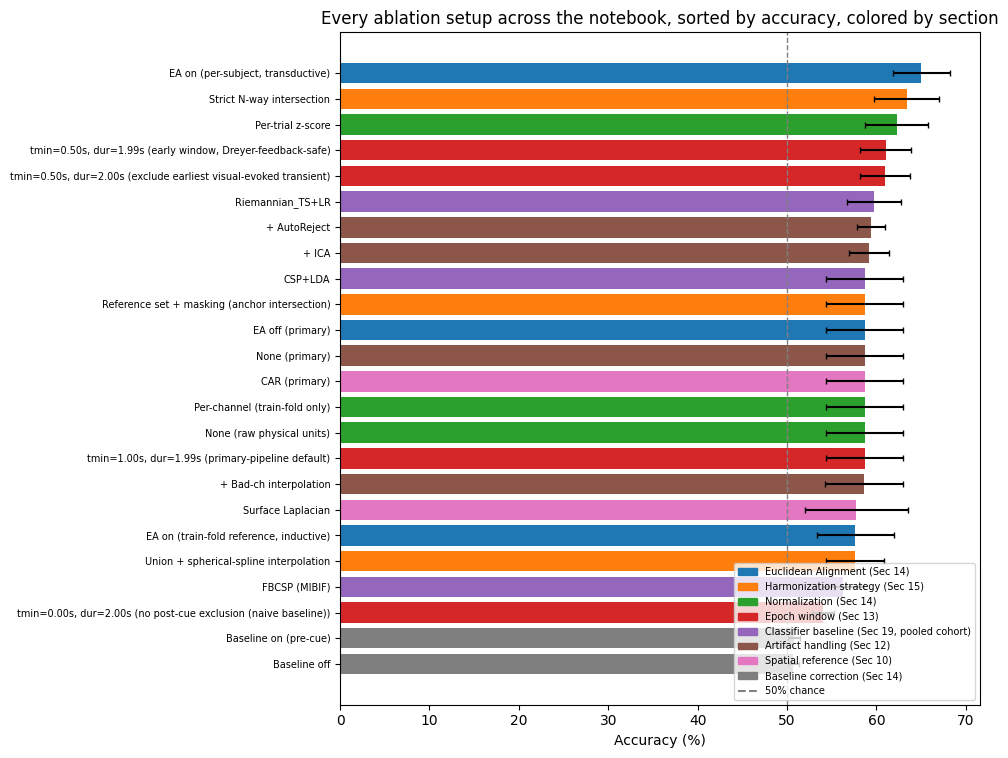

In [58]:
import matplotlib.pyplot as plt

plot_df = ledger_df.dropna(subset=["Accuracy_num"]).copy()
plot_df["Std_num"] = plot_df["Std"].map(_pct)
sections = list(plot_df["Section"].unique())
cmap = plt.get_cmap("tab10")
colors = {s: cmap(i % 10) for i, s in enumerate(sections)}

fig, ax = plt.subplots(figsize=(10, max(6, 0.32 * len(plot_df))))
y = range(len(plot_df))
ax.barh(y, plot_df["Accuracy_num"], xerr=plot_df["Std_num"].fillna(0),
       color=[colors[s] for s in plot_df["Section"]], ecolor="black", capsize=2)
ax.set_yticks(list(y))
ax.set_yticklabels([f"{row.Setup}" for row in plot_df.itertuples()], fontsize=7)
ax.invert_yaxis()
ax.axvline(50, color="gray", ls="--", lw=1, label="50% (binary chance)")
ax.set_xlabel("Accuracy (%)")
ax.set_title("Every ablation setup across the notebook, sorted by accuracy, colored by section")
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[s]) for s in sections]
ax.legend(handles + [plt.Line2D([0], [0], color="gray", ls="--")],
         sections + ["50% chance"], loc="lower right", fontsize=7)
fig.tight_layout()
plt.show()

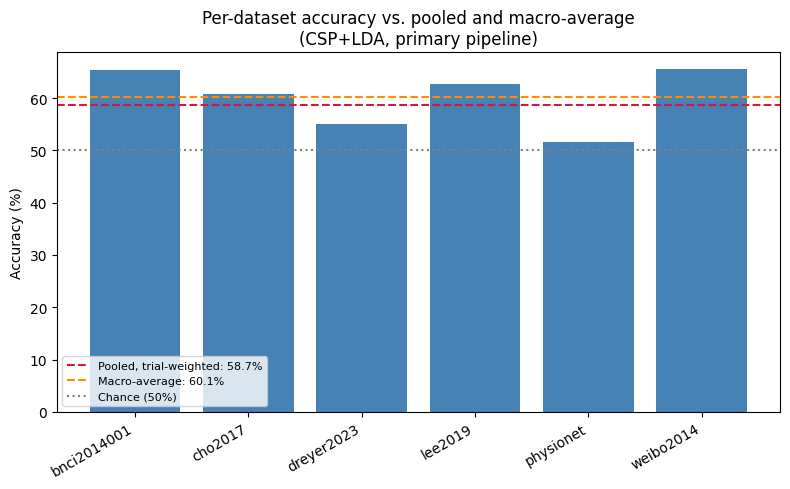

In [59]:
pd_plot = per_dataset_df.dropna(subset=["Accuracy_num"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(pd_plot["Setup"], pd_plot["Accuracy_num"], color="steelblue")
ax.axhline(pooled_weighted, color="crimson", ls="--",
          label=f"Pooled, trial-weighted: {pooled_weighted:.1f}%")
ax.axhline(macro_avg, color="darkorange", ls="--",
          label=f"Macro-average: {macro_avg:.1f}%")
ax.axhline(50, color="gray", ls=":", label="Chance (50%)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-dataset accuracy vs. pooled and macro-average\n(CSP+LDA, primary pipeline)")
ax.legend(fontsize=8)
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
plt.show()

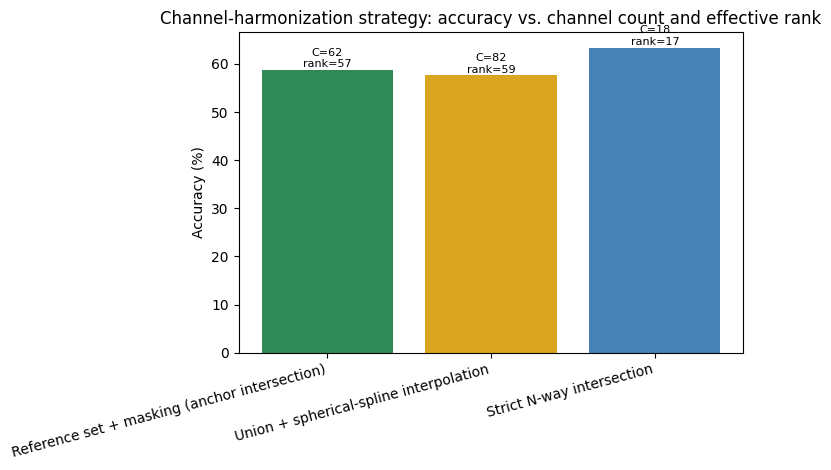

In [60]:
harm_plot = df_harmonization.copy()
harm_plot["Accuracy_num"] = harm_plot["Accuracy"].map(_pct)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
bar_colors = ["seagreen", "goldenrod", "steelblue"][:len(harm_plot)]
bars = ax.bar(harm_plot["Setup"], harm_plot["Accuracy_num"], color=bar_colors)
for bar, (_, row) in zip(bars, harm_plot.iterrows()):
    label_bits = []
    if "N_channels" in row and pd.notna(row["N_channels"]):
        label_bits.append(f"C={int(row['N_channels'])}")
    if "Median_rank" in row and pd.notna(row["Median_rank"]):
        label_bits.append(f"rank={int(row['Median_rank'])}")
    if label_bits:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.6,
               "\n".join(label_bits), ha="center", fontsize=8)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Channel-harmonization strategy: accuracy vs. channel count and effective rank")
plt.xticks(rotation=15, ha="right")
fig.tight_layout()
plt.show()

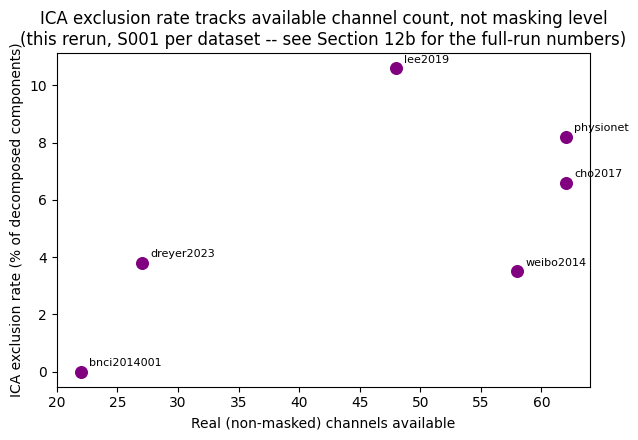

In [61]:
if 'ica_diag_df' in globals() and len(ica_diag_df):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    x = ica_diag_df["n_real_ch"]
    y = ica_diag_df["exclusion_rate"].map(_pct)
    ax.scatter(x, y, s=70, color="purple", zorder=3)
    for _, row in ica_diag_df.iterrows():
        ax.annotate(row["dataset"], (row["n_real_ch"], _pct(row["exclusion_rate"])),
                   textcoords="offset points", xytext=(6, 4), fontsize=8)
    ax.set_xlabel("Real (non-masked) channels available")
    ax.set_ylabel("ICA exclusion rate (% of decomposed components)")
    ax.set_title("ICA exclusion rate tracks available channel count, not masking level\n"
                "(this rerun, S001 per dataset -- see Section 12b for the full-run numbers)")
    fig.tight_layout()
    plt.show()
else:
    print("Run Section 12b above first to populate ica_diag_df for this chart.")

### Verdict, updated after this section's fixes

**What changed since the earlier review:** the Dreyer2023 loader now defaults to `acquisition_only=True` (Appendix item 1, resolved) — re-run from Section 2 for it to apply throughout. Per-dataset and macro-average numbers are now first-class outputs, not something you have to dig for in Section 15's console log. The ICA over-cleaning concern is closed (mechanism doesn't apply, and the real driver — component count — is now charted above); the channel-rejection frontal bias is documented and scoped to a secondary ablation that isn't in the primary pipeline.

**What's still open, unchanged by this section:** the epoch-window default (`tmin=1.0`) still underperforms `tmin=0.5` by ~2.3 points in Section 13's own ablation — that's a decision to make explicitly, not something this section resolves for you. Euclidean Alignment's inductive number is still worse than EA off. Lee2019 is still 2 subjects. None of these are preprocessing bugs; they're open scientific decisions the preprocessing program has now surfaced clearly enough to make.

In [62]:
# --- Section 22: full-load ablation suite, all artifacts saved -----------
# n_subjects_per_dataset={} means "all subjects of every enabled dataset":
# _resolve_subject_ids(None, cfg) returns list(range(1, n_subjects+1)). The
# point of the full-load pass is comparability -- every block must have been
# computed on the SAME cohort, or the rows stop being apples-to-apples.
from preprocessing_pkg.ablation_suite import (
    ablation_spatial_reference, ablation_artifact_handling,
    ablation_epoch_window, ablation_baseline_correction,
    ablation_normalization, ablation_euclidean_alignment,
)
from tqdm.auto import tqdm

FULL_LOAD = {}    # {} -> all subjects; or e.g. {"physionet": 20, ...}

blocks = {
    "spatial_reference":     ablation_spatial_reference,
    "artifact_handling":     ablation_artifact_handling,
    "epoch_window":          ablation_epoch_window,
    "baseline_correction":   ablation_baseline_correction,
    "normalization":         ablation_normalization,
    "euclidean_alignment":   ablation_euclidean_alignment,
    "frequency_band":        lambda *a, **k: pkg.ablation_frequency_band(
        *a, **k, classifier_name="CSP+LDA"),
    "ica_with_without_notch": lambda *a, **k: pkg.ablation_ica_with_without_notch(
        *a, **k, line_freq=line_freq),
}

all_results = {}
for name, fn in tqdm(blocks.items(), desc="Full ablation suite", unit="block"):
    print(f"\n================ ABLATION BLOCK: {name} ================")
    df = fn(registry, channel_mapping_df, montage, glob, FULL_LOAD,
            common_channels, car_scope)
    all_results[name] = df
    print(df.to_string(index=False))
    pkg.save_table(df, f"ablation_{name}")

pkg.save_json(
    {name: df.to_dict(orient="records") for name, df in all_results.items()},
    "ablation_suite_all_blocks")
print(f"\n[output] full ablation suite written to {OUTPUT_ROOT}/tables/")

Full ablation suite:   0%|          | 0/8 [00:00<?, ?block/s]


================ ABLATION BLOCK: spatial_reference ================


Spatial-reference ablation:   0%|          | 0/2 [00:00<?, ?setup/s]

[cohort build] physionet/S088 excluded by config: recorded at 128 Hz (not 160 Hz) with shifted 5.125s/1.375s task/rest timing
[cohort build] physionet/S089 excluded by config: independently reported incorrect/mislabeled event annotations
[cohort build] physionet/S092 excluded by config: recorded at 128 Hz (not 160 Hz) with shifted 5.125s/1.375s task/rest timing
[cohort build] physionet/S100 excluded by config: recorded at 128 Hz (not 160 Hz) with shifted 5.125s/1.375s task/rest timing
[cohort build] dreyer2023/S059 excluded by config: only 4 of 6 runs present (MOABB skips its R5/R6 online runs)
[cohort build] Dispatching 316 subject(s) across 6 dataset(s) with n_jobs=4 (variant='primary').


[primary] cohort:   0%|          | 0/316 [00:00<?, ?subject/s]

Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to create continuous data -- edge effects present
Trials demeaned and stacked with zero buffer to cr

In [ ]:
# ============================================================
# SAVE ENTIRE /kaggle/working AS A KAGGLE DATASET
# ============================================================

import os
import json
import shutil
import subprocess
from pathlib import Path
from datetime import datetime

# ============================================================
# CONFIGURATION
# ============================================================

WORKING_DIR = Path("/kaggle/working")

# Kaggle dataset configuration
DATASET_DIR = Path("/kaggle/working/kaggle_dataset")

DATASET_SLUG = "my-kaggle-working-backup"

# IMPORTANT:
# Change this to your Kaggle username
KAGGLE_USERNAME = "Amirrzh"

DATASET_TITLE = "Kaggle Working Directory Backup"

DATASET_DESCRIPTION = (
    "Complete backup of the Kaggle notebook working directory "
    f"created on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
)

# ============================================================
# PREPARE DATASET DIRECTORY
# ============================================================

print("=" * 70)
print("KAGGLE WORKING DIRECTORY → KAGGLE DATASET")
print("=" * 70)

print(f"Source : {WORKING_DIR}")
print(f"Dataset: {KAGGLE_USERNAME}/{DATASET_SLUG}")
print()

# Remove old packaging directory if it exists
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

DATASET_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# COPY EVERYTHING FROM /kaggle/working
# ============================================================

print("Copying files...")

copied_files = 0
copied_bytes = 0

for item in WORKING_DIR.iterdir():

    # Do not copy the dataset we're currently creating
    if item.resolve() == DATASET_DIR.resolve():
        continue

    destination = DATASET_DIR / item.name

    if item.is_dir():
        shutil.copytree(
            item,
            destination,
            ignore=shutil.ignore_patterns(
                # Don't include this notebook's internal files
                ".virtual_documents",
                ".git",
                "__pycache__",
            ),
        )

        for f in destination.rglob("*"):
            if f.is_file():
                copied_files += 1
                copied_bytes += f.stat().st_size

    else:
        shutil.copy2(item, destination)

        copied_files += 1
        copied_bytes += item.stat().st_size

print(f"Files copied : {copied_files:,}")
print(f"Total size   : {copied_bytes / (1024**3):.2f} GB")
print()

# ============================================================
# CREATE dataset-metadata.json
# ============================================================

metadata = {
    "title": DATASET_TITLE,
    "id": f"{KAGGLE_USERNAME}/{DATASET_SLUG}",
    "subtitle": "Complete Kaggle working directory backup",
    "description": DATASET_DESCRIPTION,
    "licenses": [
        {
            "name": "CC0-1.0"
        }
    ]
}

metadata_path = DATASET_DIR / "dataset-metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Created:")
print(metadata_path)
print()

# ============================================================
# CHECK KAGGLE CLI
# ============================================================

print("Checking Kaggle CLI...")

result = subprocess.run(
    ["kaggle", "--version"],
    capture_output=True,
    text=True
)

print(result.stdout.strip())
print()

# ============================================================
# CREATE KAGGLE DATASET
# ============================================================

print("=" * 70)
print("UPLOADING DATASET")
print("=" * 70)

command = [
    "kaggle",
    "datasets",
    "create",
    "-p",
    str(DATASET_DIR),
    "-u"
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print("ERROR:")
    print(result.stderr)

    raise RuntimeError(
        "Kaggle Dataset upload failed."
    )

# ============================================================
# DONE
# ============================================================

print()
print("=" * 70)
print("DATASET CREATED SUCCESSFULLY")
print("=" * 70)

print(
    f"https://www.kaggle.com/datasets/"
    f"{KAGGLE_USERNAME}/{DATASET_SLUG}"
)